# Real Estate Predictive Modeling: Cross-Market Valuation
### *A Comparative Spatial and Economic Analysis of the Delhi Residential Real Estate Market*

#### **Author:** Joe Hardcastle
**[Link to your LinkedIn Profile]** | **jhrdcstl77@gmail.com**

<center><img src="Delhi.jpg" width="450" alt="Delhi"></center>

# Table of Contents

- **1. Introduction**
  - 1.1 Project Context & Objective
  - 1.2 Defining the Four Sub-Markets
- **2. Project Setup & Imports**
  - 2.1 Data Manipulation (pandas, numpy)
  - 2.2 Data Visualisation (matplotlib, seaborn, plotly)
  - 2.3 Statistical Modelling (scikit-learn, scipy, statsmodels)
- **3. Data Ingestion & Overview**
  - 3.1 Data Source
  - 3.2 Loading the Dataset
  - 3.3 Inspecting the Data Structure
- **4. Cleaning the Data**
  - 4.1 Checking for missing values (NaN)
  - 4.2 Checking for and Dropping Duplicates
  - 4.3 Checking Unique Values Across Discrete & Boolean Features
    - 4.3.1 Fixing Categorical & Discrete Value Issues
  - 4.4 Rescaling Target Variable: Price (Lakhs)
  - 4.5 Defining Valid Price Boundaries
  - 4.6 Establishing Target Locations
- **5. Exploratory Data Analysis (EDA)**
  - 5.1 Distribution of Prices (40–80 Lakhs) Across Target Locations
  - 5.2 Distribution of Prices (40–80 Lakhs) in relation to Area
  - 5.3 Distribution of Area of Properties with Respect to Location and Number of Bedrooms
  - 5.4 Comparative Analysis of Property Amenities Across Locations
  - 5.5 Distribution of Prices in Relation to Essential Amenities
- **6. Multiple Linear Regression Analysis for Select Locations**
  - 6.1 Bivariate Baseline Analyses
  - 6.2 Multivariate Model Expansion
    - 6.2.1 Multivariate Regression of Dwarka Mor
    - 6.2.2 Multivariate Regression of Uttam Nagar
- **7. Predictive Deployment & Evaluation**
  - 7.1 Estimating Average House Prices
    - 7.1.1 Dwarka Mor
    - 7.1.2 Uttam Nagar
  - 7.2 Estimating Prices with Specific Features (Advanced Premium)
    - 7.2.1 Dwarka Mor
    - 7.2.2 Uttam Nagar
  - 7.3 The Final Test: Comparing both locations with identical features of a customer's requirements
    - 7.3.1 Example #1
    - 7.3.2 Example #2
- **8. Conclusions**
- **9. Appendices**


# 1. Introduction

## 1.1 Project Context & Objective

This study provides a comprehensive evaluation of the residential housing market across four prominent sub-markets in Delhi: Burari, Dwarka Mor, Uttam Nagar, and Vasant Kunj.
While the raw, uncleaned dataset contained dozens of diverse neighborhoods across the National Capital Region (NCR), the data-cleaning phase revealed that these specific four locations contained the most robust, high-volume sample sizes within our targeted budget price range of 40 to 80 Lakhs.
By isolating this specific lower-middle class income price band across these top four sub-markets, the primary objective of this project is to evaluate how physical space allocation, structural configurations, and premium amenities influence the valuation of the properties.

## 1.2 Defining the Four Sub-Markets

To appreciate fully the findings that arose from the data analysis, it is essential to be aware about the real-world economic profile of the four locations under review:

Burari (North Delhi)
A high-density, highly affordable suburban zone on the periphery of Delhi. It is dominated by low-rise private builder floors. It is a location highly suited to first time buyers on a budget.

Uttam Nagar (West Delhi)
This is a high-volume residential hub that runs along the Blue Line Metro corridor. Homes here are highly compressed, built to maximize room counts.

Vasant Kunj (South Delhi)
Vasant Kunj is the most affluent of these four neighbourhoods, it represents the highest level of luxury of the dataset.

Dwarka Mor (West Delhi)
This district is the immediate neighbour of Uttam Nagar. It serves as the primary commuter zone to the city of Dwarka. While it has a similar high-density  to Uttam Nagar and is also on the metro-corridor profile, it sits along slightly wider roads and itself is in a transitional area that leads into a an area of higher-end housing.


# 2. Project Setup & Imports

All of the analyses, data exploratoration, and multiple regressions were executed within a Python programming environment. Data manipulations were handled via pandas and numpy, visual representations were rendered using matplotlib, plotly.express and seaborn, and the formal regression model calculations were computed utilizing statsmodels, including sklearn.linear_model, sklearn.model_selection, scipy.stats and statsmodels.api.

## 2.1 Data Manipulation
* **pandas**
* **numpy**

In [1]:
import pandas as pd
import numpy as np

## 2.2 Data Visualisation
* **matplotlib**
* **seaborn**
* **plotly.express**

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## 2.3 Statistical Modelling
* **sklearn.linear_model**
* **sklearn.model_selection**
* **scipy.stats**
* **statsmodels.api**

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import scipy.stats as stats
import statsmodels.api as sm

# 3. Data Ingestion & Overview

## 3.1 Data Source

The housing dataset used in this study was sourced from Kaggle, an open-source public data repository. The data features a collection of residential property listings from across the National Capital Region (NCR) of Delhi.
Because the original platform page does not indicate the property website, or websites, that were originally web-scraped to build this raw data sample, the dataset is cited here under standard public domain guidelines. Full hosting credit and data provenance are attributed directly to the public entry on the open-source Kaggle repository. (See Appendices I)

## 3.2 Loading the Dataset

The raw comma-separated values (CSV) file was loaded into the workspace environment as a Pandas DataFrame and read using the pd.read_csv() function.

In [4]:
data = pd.read_csv('delhi-housing.csv')

## 3.3 Inspecting the Data Structure

Before applying any filters, it is essential to inspect the data types and column structures to identify and missing values and duplicated rows etc.

Firstly, the basic layout (column categories) of the data set needs to be established

In [110]:
print(data.head(5).to_string())

      Price  Area          Location  No. of Bedrooms  Resale  MaintenanceStaff  Gymnasium  SwimmingPool  LandscapedGardens  JoggingTrack  RainWaterHarvesting  IndoorGames  ShoppingMall  Intercom  SportsFacility  ATM  ClubHouse  School  24X7Security  PowerBackup  CarParking  StaffQuarter  Cafeteria  MultipurposeRoom  Hospital  WashingMachine  Gasconnection  AC  Wifi  Children'splayarea  LiftAvailable  BED  VaastuCompliant  Microwave  GolfCourse  TV  DiningTable  Sofa  Wardrobe  Refrigerator
0  10500000  1200  Sector 10 Dwarka                2       1                 0          1             0                  0             1                    0            0             0         1               1    0          0       0             1            1           1             0          0                 0         0               0              1   0     0                   1              1    0                1          0           0   0            0     0         0             0
1   600000

Using knowledge of the Indian housing market, the first category ("Price") is in Indian rupees and the "Area" relates to size of property and will be expressed in square feet. "Location" and "No. of Bedrooms" are self-explanatory. Data in all other columns are signalled by binary indicators (yes/no). Aside from "Resale", they all relate to various amenities.

Establishing the size of the data set is crucial, so that the exact number of rows and columns can be ascertained.

In [6]:
data.shape

(4998, 40)

This is quite a sizeable data set containing descriptions of almost 5000 properties. Of the 40 columns, the vast majority represent different amenities.

The next crucial step is to observe the general state of the data.

In [111]:
print(data.describe().to_string())

              Price          Area  No. of Bedrooms      Resale  MaintenanceStaff    Gymnasium  SwimmingPool  LandscapedGardens  JoggingTrack  RainWaterHarvesting  IndoorGames  ShoppingMall     Intercom  SportsFacility         ATM    ClubHouse       School  24X7Security  PowerBackup   CarParking  StaffQuarter    Cafeteria  MultipurposeRoom    Hospital  WashingMachine  Gasconnection           AC         Wifi  Children'splayarea  LiftAvailable          BED  VaastuCompliant    Microwave   GolfCourse           TV  DiningTable         Sofa     Wardrobe  Refrigerator
count  4.998000e+03   4998.000000      4998.000000  4998.00000       4998.000000  4998.000000   4998.000000        4998.000000   4998.000000          4998.000000  4998.000000   4998.000000  4998.000000     4998.000000  4998.00000  4998.000000  4998.000000   4998.000000  4998.000000  4998.000000   4998.000000  4998.000000       4998.000000  4998.00000     4998.000000    4998.000000  4998.000000  4998.000000         4998.000000    

The extremes in prices range from 2.000000e+06 to 8.546000e+08, which represent 20,00,000 rupees (₹20 Lakhs) and 85,46,00,000 rupees (₹85.46 Crores). The concepts of Lakhs and Crores will be explained further on. Property sizes start at 200 square feet and finish at 16000 square feet. The number of bedrooms span from 1 to 8. 

As all other columns (excluding "Location") are expressed with a binary indicator, there are some anomalies in the above summary statistics: although not all columns are shown, every category that can be seen (excluding "Resale") has a maximum value (and mid/upper quartiles) of 9, which clearly indicates that the binary nature of data in these columns has been polluted in some way.

To see the data types in each column is essential:

In [112]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4998 entries, 0 to 4997
Data columns (total 40 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Price                4998 non-null   int64
 1   Area                 4998 non-null   int64
 2   Location             4998 non-null   str  
 3   No. of Bedrooms      4998 non-null   int64
 4   Resale               4998 non-null   int64
 5   MaintenanceStaff     4998 non-null   int64
 6   Gymnasium            4998 non-null   int64
 7   SwimmingPool         4998 non-null   int64
 8   LandscapedGardens    4998 non-null   int64
 9   JoggingTrack         4998 non-null   int64
 10  RainWaterHarvesting  4998 non-null   int64
 11  IndoorGames          4998 non-null   int64
 12  ShoppingMall         4998 non-null   int64
 13  Intercom             4998 non-null   int64
 14  SportsFacility       4998 non-null   int64
 15  ATM                  4998 non-null   int64
 16  ClubHouse            4998 non-null 

The info() printout shows that the dataset contains exactly 4,998 entries with no missing (NaN) values across any of the 40 columns. Out of these columns, 39 are categorized as integer data types (int64), which include continuous variables like "Price" and "Area", alongside the binary indicators. The single remaining column is "Location", which is parsed cleanly as text object data.
While this complete structure means that there is no need to drop any rows due to traditional missing values, the data cleaning phase cannot be skipped entirely. The presence of the value 9 in the binary columns indicates that data corruption or hidden placeholders exist. Therefore, these anomalies must be adressed before confidently moving forward with filtering or modeling.

# 4. Cleaning the Data

## 4.1 Checking for missing values (NaN)

A control was done to completely rule out the presence of hidden missing values before data partitioning.

In [9]:
is_nan = data.isna().any(axis=None).sum()
print(f"Number of missing values: {is_nan}")

Number of missing values: 0


The above output confirmed a total count of 0 missing values, validating that the dataset contains no empty entries that would require imputation or row deletion before any data exploration.

## 4.2 Checking for and Dropping Duplicates

With data completeness verified via the missing-value check, the next essential data quality test is to check for the existence of any duplicate rows within the data set. Replicated observations are common in scraped real estate listings and, if left unaddressed, these duplicates can cause serious problems to the dataset and result in misinterprations of the data. 

An inspection of the dataset for any duplicated rows audit was performed.

In [10]:
nr_duplicates = data.duplicated().sum()
print(f"Number of duplicated rows: {nr_duplicates}")


Number of duplicated rows: 889


The execution of this audit revealed a substantial data quality issue, identifying exactly 889 duplicate rows within the raw dataset. This finding confirms that a significant portion of the initial sample consists of overlapping listings. Because allowing these duplicate rows to remain would introduce statistical bias and affect the pricing distributions, these rows must be deleted before proceeding with further analysis.

In [11]:
data_cleaned = data.drop_duplicates()
data_cleaned.shape

(4109, 40)

Deleting the duplicates has left 4109 properties in the dataset.

## 4.3 Checking Unique Values Across Discrete & Boolean Features

Columns that hold numerical data, such as "Price" and "Area", obviously have a large spread; but for all of the columns that have binary indicators the problem of data pollution has been previously identified in the description of the data. There is anomalous data that has given the 50%, upper quartile and maximum value of 9. It is crucial here that we check the unique values for each of these columns.

Columns that hold numerical data, such as "Price" and "Area", naturally have a wide spread. However, as previously identified in the summary statistics, the columns meant to serve as binary indicators suffer from a data pollution issue. This anomalous data has caused the median (50%), upper quartile, and maximum values to register as 9. To investigate the scope of this corruption, it is crucial to isolate and examine the unique values across each of these columns.

In [12]:
for col in data.columns[4:40]:
    print(f"Column '{col}' unique values: {data[col].unique()}")

Column 'Resale' unique values: [1 0]
Column 'MaintenanceStaff' unique values: [0 1 9]
Column 'Gymnasium' unique values: [1 0 9]
Column 'SwimmingPool' unique values: [0 1 9]
Column 'LandscapedGardens' unique values: [0 1 9]
Column 'JoggingTrack' unique values: [1 0 9]
Column 'RainWaterHarvesting' unique values: [0 1 9]
Column 'IndoorGames' unique values: [0 1 9]
Column 'ShoppingMall' unique values: [0 1 9]
Column 'Intercom' unique values: [1 0 9]
Column 'SportsFacility' unique values: [1 0 9]
Column 'ATM' unique values: [0 1 9]
Column 'ClubHouse' unique values: [0 1 9]
Column 'School' unique values: [0 1 9]
Column '24X7Security' unique values: [1 0 9]
Column 'PowerBackup' unique values: [1 0 9]
Column 'CarParking' unique values: [1 0 9]
Column 'StaffQuarter' unique values: [0 1 9]
Column 'Cafeteria' unique values: [0 1 9]
Column 'MultipurposeRoom' unique values: [0 1 9]
Column 'Hospital' unique values: [0 1 9]
Column 'WashingMachine' unique values: [0 1 9]
Column 'Gasconnection' unique 

What can be seen here is that in addition to 0s and 1s, 9s have been entered. This most likely signifies a missing value placeholder. Interestingly, some amenities do not possess both binary states (0 and 1). These anomalies must be addressed in the next stages of the cleaning process.

### 4.3.1 Fixing Categorical & Discrete Value Issues

To ensure data purity, rows containing the placeholder value 9 within the amenity columns will be dropped. Allowing these corrupted records to remain would hamper data analyses and the effectiveness of statistical models.

In [13]:
data_cleaned = data_cleaned.replace(9, np.nan)
data_cleaned = data_cleaned.dropna()
# data_cleaned.shape
for col in data_cleaned.columns[5:]:
    print(f"Column '{col}' unique values: {data_cleaned[col].unique()}")

Column 'MaintenanceStaff' unique values: [0. 1.]
Column 'Gymnasium' unique values: [1. 0.]
Column 'SwimmingPool' unique values: [0. 1.]
Column 'LandscapedGardens' unique values: [0. 1.]
Column 'JoggingTrack' unique values: [1. 0.]
Column 'RainWaterHarvesting' unique values: [0. 1.]
Column 'IndoorGames' unique values: [0. 1.]
Column 'ShoppingMall' unique values: [0. 1.]
Column 'Intercom' unique values: [1. 0.]
Column 'SportsFacility' unique values: [1. 0.]
Column 'ATM' unique values: [0. 1.]
Column 'ClubHouse' unique values: [0. 1.]
Column 'School' unique values: [0. 1.]
Column '24X7Security' unique values: [1. 0.]
Column 'PowerBackup' unique values: [1. 0.]
Column 'CarParking' unique values: [1. 0.]
Column 'StaffQuarter' unique values: [0. 1.]
Column 'Cafeteria' unique values: [0. 1.]
Column 'MultipurposeRoom' unique values: [0. 1.]
Column 'Hospital' unique values: [0. 1.]
Column 'WashingMachine' unique values: [0. 1.]
Column 'Gasconnection' unique values: [1. 0.]
Column 'AC' unique va

Having deleted all occurrences of any 9s, only 0s and 1s remain in the targetted columns. But, critically, certain amenities now only possess one unique value, for example "Wardrobe", which only has 0s.

It's important now to take a look at a snapshot of the updated DataFrame.

In [14]:
data_cleaned.sample(5)

,Price,Area,Location,No. of Bedrooms,Resale,MaintenanceStaff,Gymnasium,SwimmingPool,LandscapedGardens,JoggingTrack,...,LiftAvailable,BED,VaastuCompliant,Microwave,GolfCourse,TV,DiningTable,Sofa,Wardrobe,Refrigerator
1153,2200000,550,Uttam Nagar,2,0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
481,7500000,1300,Dwarka Mor,4,0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
302,16200000,1900,Sector 6 Dwarka,3,1,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
547,20000000,2000,Sector 12 Dwarka,4,1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
954,3100000,616,Mansa Ram Park,2,1,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


During the previous step, the amenity values have all been converted to float numbers. This needs to be confirmed.

In [15]:
data_cleaned.info()

<class 'pandas.DataFrame'>
Index: 1716 entries, 0 to 1999
Data columns (total 40 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Price                1716 non-null   int64  
 1   Area                 1716 non-null   int64  
 2   Location             1716 non-null   str    
 3   No. of Bedrooms      1716 non-null   int64  
 4   Resale               1716 non-null   int64  
 5   MaintenanceStaff     1716 non-null   float64
 6   Gymnasium            1716 non-null   float64
 7   SwimmingPool         1716 non-null   float64
 8   LandscapedGardens    1716 non-null   float64
 9   JoggingTrack         1716 non-null   float64
 10  RainWaterHarvesting  1716 non-null   float64
 11  IndoorGames          1716 non-null   float64
 12  ShoppingMall         1716 non-null   float64
 13  Intercom             1716 non-null   float64
 14  SportsFacility       1716 non-null   float64
 15  ATM                  1716 non-null   float64
 16  Club

The above output clearly shows that for columns 5 to 39 the datatypes have been converted from Int64 to float64. This happened during the process in which numpy was used to replace all 9s in the amenity columns to NaNs (missing values) and subsequently drop the offending rows from our dataset. This must be reversed.

In [16]:
boolean_cols = data_cleaned.columns[5:]
data_cleaned[boolean_cols] = data_cleaned[boolean_cols].astype('Int64')
data_cleaned.head(1)

,Price,Area,Location,No. of Bedrooms,Resale,MaintenanceStaff,Gymnasium,SwimmingPool,LandscapedGardens,JoggingTrack,...,LiftAvailable,BED,VaastuCompliant,Microwave,GolfCourse,TV,DiningTable,Sofa,Wardrobe,Refrigerator
0,10500000,1200,Sector 10 Dwarka,2,1,0,1,0,0,1,...,1,0,1,0,0,0,0,0,0,0


The above output shows the successful reconversion back to integer values in the amenity columns.

The next challenge is to delete all columns which do not have unique value pairings of 0 and 1. Such features will offer no value should they be chosen to be used for making comparisons.

In [17]:
cols_to_drop = []

for col in data_cleaned.columns[5:]:
    unique_vals = set(data_cleaned[col].unique())
    
    if not {0, 1}.issubset(unique_vals):
        cols_to_drop.append(col)

data_cleaned = data_cleaned.drop(columns=cols_to_drop)

print(f"Dropped columns: {cols_to_drop}")

Dropped columns: ['Wifi', 'GolfCourse', 'Wardrobe']


The above code deleted the columns which didn't satisfy the binary requirements. These columns were: "Wifi", "GolfCourse" and "Wardrobe".

The new DataFrame columns need to be checked to confirm that the columns have been dropped.

In [18]:
data_cleaned.head(1)

,Price,Area,Location,No. of Bedrooms,Resale,MaintenanceStaff,Gymnasium,SwimmingPool,LandscapedGardens,JoggingTrack,...,AC,Children'splayarea,LiftAvailable,BED,VaastuCompliant,Microwave,TV,DiningTable,Sofa,Refrigerator
0,10500000,1200,Sector 10 Dwarka,2,1,0,1,0,0,1,...,0,1,1,0,1,0,0,0,0,0


In [19]:
numbers_of_columns = data_cleaned.shape[1]
print(f"New number of columns: {numbers_of_columns}")

New number of columns: 37


The dataset now has 37 columns instead of the original 40. The above printout confirms that 'Wifi', 'GolfCourse' and 'Wardrobe' have been successfully dropped.

## 4.4 Rescaling Target Variable: Price (Lakhs)

In India, the expression of quantities is different to that of Western societies. The prices in the dataset are given in Indian rupees(₹). However, the concept of Lakhs and Crores must be understood: 1 Lakh rupees is equivalent to 100,000 rupees, whereas 1 Crore rupees is equivalent to 10,000,000 rupees. The price band this project will concern is centered on properties affordable to a lower middle class purchaser. Because of this, the prices will all be converted to Lakh rupees, as this type of buyer will almost certainly buy a cheaper property (priced in Lakhs) as opposed to a more expensive property (priced in Crores).
A quick check to see it operational in our dataset will be of use as well.

In [20]:
data_cleaned = data_cleaned.rename(columns={'Price': 'Price (Lakhs)'})
data_cleaned['Price (Lakhs)'] = data_cleaned['Price (Lakhs)'] / 100000
data_cleaned.head(1)

,Price (Lakhs),Area,Location,No. of Bedrooms,Resale,MaintenanceStaff,Gymnasium,SwimmingPool,LandscapedGardens,JoggingTrack,...,AC,Children'splayarea,LiftAvailable,BED,VaastuCompliant,Microwave,TV,DiningTable,Sofa,Refrigerator
0,105.0,1200,Sector 10 Dwarka,2,1,0,1,0,0,1,...,0,1,1,0,1,0,0,0,0,0


The printout confirms the successful transformation of our target variable, showing the property price clearly expressed in Lakhs. Now the prices can be interpreted at a glance, without having to read long numbers with scientific E-notation.

## 4.5 Defining Valid Price Boundaries

The Indian lower-middle class typically buys homes in the 40-80 Lakhs region. The price extremes of our raw data have already been mentioned, albeit briefly, but to see the maximum and minimum prices expressed in lakhs would be extremely valuable in relation to filtering our dataset, so it applies only to a typical lower middle class buyer.

In [21]:
price_min = data_cleaned['Price (Lakhs)'].min()
print(f"The cheapest property in our dataset is valued at {price_min} Lakhs")

The cheapest property in our dataset is valued at 20.0 Lakhs


In [22]:
price_max = data_cleaned['Price (Lakhs)'].max()
print(f"The most expensive property in our dataset is valued at {price_max} Lakhs")

The most expensive property in our dataset is valued at 1625.0 Lakhs


From the above information, there are properties well out of the focus range of this project. The most expensive home, especially, is over twenty times the value of the maximum property limit that will be considered in this study.

In [23]:
prices = data_cleaned.groupby('Price (Lakhs)').size()
prices

Price (Lakhs)
20.0      14
20.3       1
21.0      11
21.5       1
22.0      22
          ..
475.0      1
650.0      1
750.0      1
1100.0     1
1625.0     1
Length: 275, dtype: int64

As it stands, the data has been largely cleaned. What remains now is to filter it down to the required price range. Before doing this, it would help to observe the price distribution of the entire dataset, to see visually what the spread of prices is like.

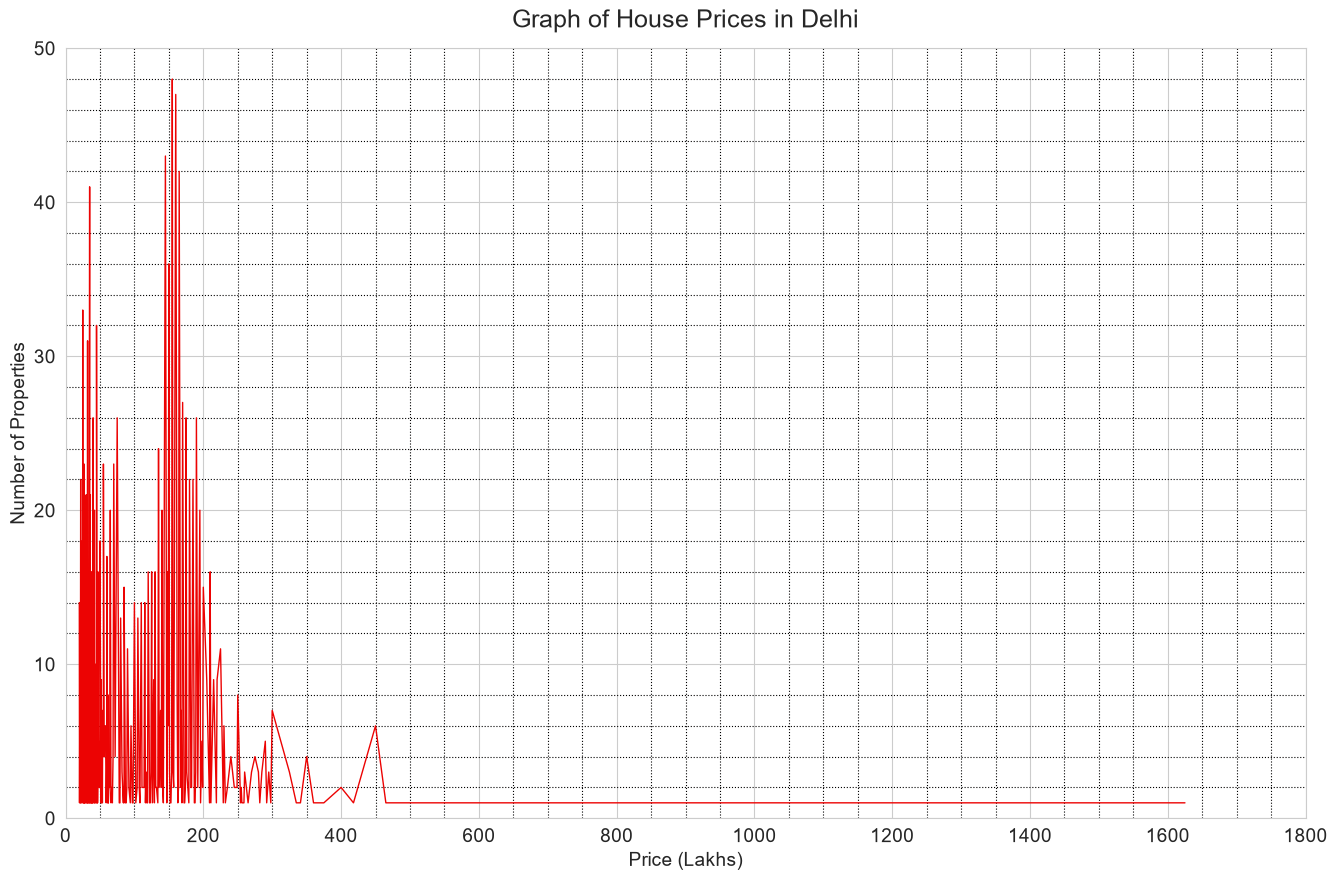

In [24]:
prices = data_cleaned['Price (Lakhs)'].value_counts().sort_index()
with sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(figsize=(16, 10))
    ax.plot(prices.index, prices.values, color="#EC0303", linewidth=1)
    ax.minorticks_on()
    ax.grid(visible=True, which='both')
    ax.grid(visible=True, which='minor', color="#010000", linestyle=':', linewidth=0.8)
    ax.set_title('Graph of House Prices in Delhi', fontsize=18, pad=15)
    ax.set_xlabel('Price (Lakhs)', fontsize=14)
    ax.set_ylabel('Number of Properties', fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.set_xlim(0, 1800)
    ax.set_ylim(0, 50)
    
    plt.show()

The line graph shows the majority of properties clustered between the 20 and 200 Lakhs mark. Beyond 200 Lakhs, the number of properties decreases, but in an irregular manner. After approximately 460 Lakhs there are no properties, except the property with the maximum value of 1625 Lakhs. It looks like over half of these properties sit outside the limits of this study, so the dataset will be, necessarily, reduced following the filtering of it based on price parameters. 

The next step, naturally, will be to filter the data so that the price of each property sits between 40 and 80 Lakhs.

In [25]:
data_cleaned = data_cleaned[(data_cleaned['Price (Lakhs)'] >= 40) & (data_cleaned['Price (Lakhs)'] <= 80)]

Now the data has been fully cleaned and filtered, it is now important to see how many properties remain in the study.

In [26]:
cleaned_data_shape = data_cleaned.shape
print(f"The number of properties remaining in the dataset: {cleaned_data_shape[0]}")

The number of properties remaining in the dataset: 392


The original raw dataset contained 4998 properties, but after the necessary steps to make it suitable for the study there are now 392 properties. Over 4500 properties have been eliminated from our study.

## 4.6 Establishing Target Locations

The dataset has been greatly reduced, so now there is the challenge of determining what locations can be chosen for the study. The number of properties at each location has to be established.

In [27]:
data_cleaned['Location'].value_counts()

Location
Dwarka Mor           104
Uttam Nagar           75
Burari                34
Vasant Kunj           32
Chattarpur            17
nawada                15
Sector 23 Rohini      11
Sector 24 Rohini      10
Mansa Ram Park         9
Shahdara               8
Mahavir Enclave        7
Shastri Nagar          6
Paschim Vihar          5
Sewak Park             4
Rohini sector 24       4
Mehrauli               4
Hari Nagar             4
Pitampura              3
Jamia Nagar            3
Sector 20 Rohini       3
Sector 22 Rohini       3
Sector 9 Dwarka        2
Mundka                 2
Budh Vihar             2
Bindapur               2
Sector 17 Dwarka       2
Babarpur               1
Sector-18 Dwarka       1
Sector 3 Dwarka        1
Jasola                 1
Saidabad               1
Palam                  1
Govindpuri             1
Matiala                1
South Extension 2      1
Lajpat Nagar III       1
DLF Farms              1
Kalkaji                1
Saket                  1
Sector 6 Dwarka 

The above printout shows only a small number of locations that possess meaningful property numbers. Strictness has to be applied here:
1. Comparative Baseline Threshold: To compare locations effectively, a minimum of 30 samples per location is required to allow for sufficient data variation to adequately perform an analysis. This isolates four target locations with which valid comparisons can be made: Dwarka Mor, Uttam Nagar, Burari, and Vasant Kunj.
2. Multivariate Regression Requirements: For performing robust multiple regression analyses, a general rule of thumb requires at least 15 observations per independent predictor variable. Leaving the specific feature selection until later, the only two locations that permit any form of interesting, reliable multiple regression analysis are Dwarka Mor and Uttam Nagar.

As the 4 locations have been chosen for analysis, creating a new DataFrame which contains only these locations is essential.

In [28]:
target_locations = ['Dwarka Mor', 'Uttam Nagar', 'Burari', 'Vasant Kunj']
top4_loc = data_cleaned[data_cleaned['Location'].isin(target_locations)].copy()
print("Properties per location in your new DataFrame:")
print(top4_loc['Location'].value_counts())

Properties per location in your new DataFrame:
Location
Dwarka Mor     104
Uttam Nagar     75
Burari          34
Vasant Kunj     32
Name: count, dtype: int64


Having formed this DataFrame, the data can finally be analysed.

# 5. Exploratory Data Analysis (EDA)

Now that the data is ready, it can be treated to various analyses. Before proceeding to do any graphical outputs, in the name of consistency it is a good idea to use the same colour scheme throughout, so a palette will be used to achieve this. Unfortunately, neither Seaborn nor Plotly is consistent with the allocation of colours to specific variables (in this case, location). To remedy this, it is essential to map colour to location at the earliest opportunity.
Note: two colour palettes have been created. One of these is in the form of a dictionary, which assigns the same colour for each location throughout, and the other is in the form of a list, for charts which aren't showing differences between areas.

In [29]:
colour_palette_dict = {'Burari': '#0B2545', 'Dwarka Mor': "#3B1BDF", 'Uttam Nagar': '#38A3A5', 'Vasant Kunj': '#E64D0B'}
colour_palette_list = ['#0B2545', "#3B1BDF", '#38A3A5', "#E64D0B"]

## 5.1 Distribution of Prices (40–80 Lakhs) Across Target Locations

The first thing that will be investigated will be the variation of property prices across all 4 locations. A box plot will be used to serve this purpose.

In [30]:
fig = px.box(
    top4_loc,
    x="Location",
    y="Price (Lakhs)",
    color="Location",
    color_discrete_map=colour_palette_dict,
    title="Property Price Distribution Across Top 4 Locations (40-80 Lakhs)",
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Location",
    yaxis_title="Price (in Lakhs)",
    title_font_size=16,
    showlegend=False,
    width=900,
    height=550,
)

fig.show()

The most striking point of these boxplots is that it is clear that 3 of the areas (Uttam Nagar, Dwarka Mor and Burari) sit comfortably within the budget price range- their median values placed within the 40-50 Lakhs price band. In contrast, Vasant Kunj has a median price of 72 Lakhs. This is strongly indicative of a more upmarket neighbourhood. Conversely, Burari appears to be the location where properties are at their cheapest: it has both an upper fence and a maximum price of 60 Lakhs, which are both substantially lower than that of Uttam Nagar and Dwarka Mor. Dwarka Mor has the biggest spread of price range, with a price high of 80 Lakhs, but as it is the cut off point of our price limits, it could be possibly even higher. Uttam Nagar has a slightly lower upper fence and maximum price, but as both of these are under 80 Lakhs, it looks as though its is a slightly cheaper neighbourhood to live in than Dwarka Mor. Every location, aside from Vasant Kunj, has both the lower fence and minimum value of 40 Lakhs. Again, as that is the lower level of our price range, it is highly possible that cheaper properties can be bought in the neighbourhoods.

From observing these boxplots, I would place the neighbourhoods (from least to most expensive) in the following order: Burari, Uttam Nagar, Dwarka Mor and then Vasant Kunj.

## 5.2 Distribution of Prices (40–80 Lakhs) in relation to Area

To see the price of properties based on property area (for each location) a line graph will be used to show this situation.

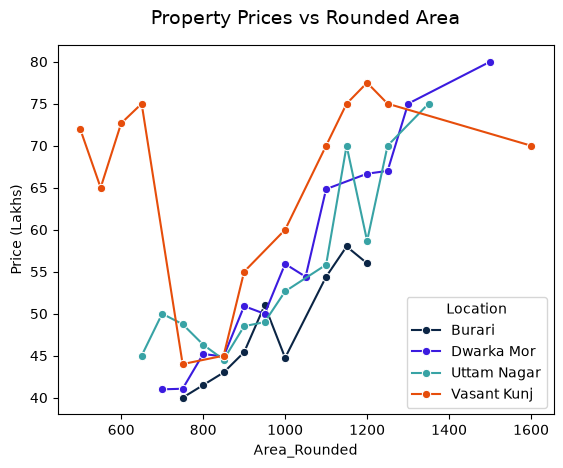

In [31]:
top4_loc['Area_Rounded'] = (top4_loc['Area'] / 50).round() * 50
smooth_data = top4_loc.groupby(['Location', 'Area_Rounded'], as_index=False)['Price (Lakhs)'].mean()
sns.lineplot(
    data=smooth_data,
    x='Area_Rounded',  
    y='Price (Lakhs)',
    hue='Location',
    palette=colour_palette_dict,  
    marker="o",        
)
plt.title("Property Prices vs Rounded Area", fontsize=14, pad=15)
plt.show()

To show more clearly the trending shown by the lines in the graph, the areas were rounded to the nearest 50 square feet (Area_Rounded). The original line graph was far too spiky due to variance in area size and it has been preserved in the Appendices for reference purposes only. (See Appendix II)

Despite the spikiness of this chart, it is clearly seen that in every location (except Vasant Kunj), there is an overall trend of price increasing as area does. There are downward turns in these lines, but they don't mask the positive relationship these variables have between them. From the positions of the lines on the graph, there is more visual evidence to claim that Burari is the most affordable neighbourhood, followed by Uttam Nagar and then Dwarka Mor. 
Vasant Kunj shows some interesting features in its line: first of all the baseline price for a property here is around the 70 Lakh mark, compared to the 40-45 Lakh mark in the other three locations. But, there is a marked dip in the line, at around the 750-850 square feet mark, but then it steadily climbs up to the prices that were seen for properties of 600 square feet, but the properties at that similar pricing were double in size. There is clearly something wrong with the data and it could be due to careless data entry or even because of deliberate false advertising to attract people to properties that aren't in the location they are listed to be in (in this case Vasant Kunj).

The above line graph shows generally the pricing trends over an increasing area. Having had its data smoothed out and shown to be less noisy than the real situation, it is wise to follow this up with a linear model plot (sns.lmplot). This permits the display of all raw, unsmoothed, data points, with an added linear regression line for each location.

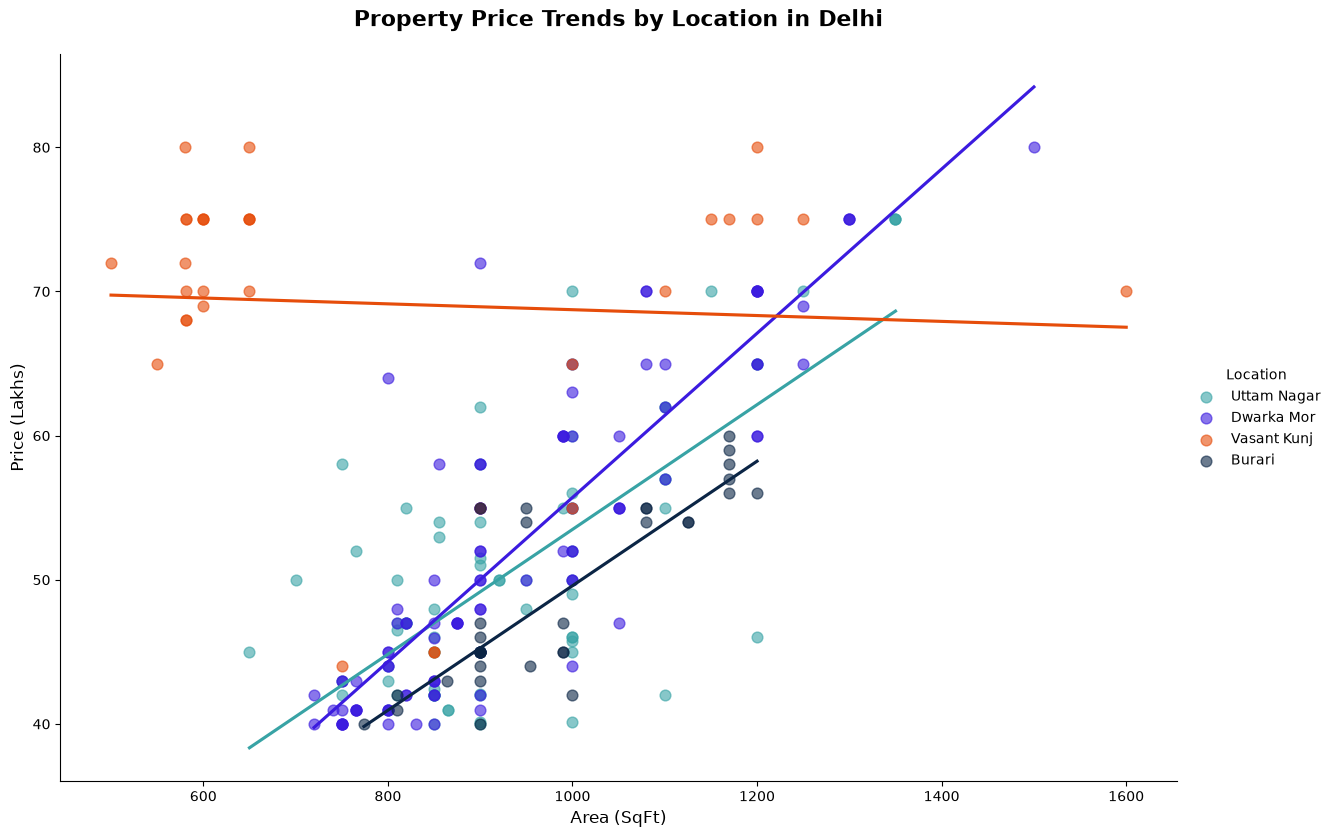

In [32]:
linegraph = sns.lmplot(
    data=top4_loc, 
    x='Area',        
    y='Price (Lakhs)',       
    hue='Location', 
    palette=colour_palette_dict,
    height=8, 
    aspect=1.5,
    scatter_kws={'alpha': 0.6, 's': 60}, 
    ci=None          
)

linegraph.set_xlabels("Area (SqFt)", fontsize=12)
linegraph.set_ylabels("Price (Lakhs)", fontsize=12)
plt.title("Property Price Trends by Location in Delhi", fontsize=16, fontweight='bold', pad=20)

plt.show()

Here, it is even more clear the order of property pricing between the 3 more affordable neighbourhoods, from most affordable to least is: Burari, Uttam Nagar and then Dwarka Mor, as deduced from the previous line graph and box plots. The regression lines of Burari and Uttam Nagar are almost perfectly parallel, which hints at an almost discrete difference between the neighbourhoods in terms of pricing and also an almost identical price per square foot. Dwarka Mor shows an interesting trend: although it is visbly a more expensive neighbourhood, its regression line bisects Uttam Nagar's at the lowest area/prices. So, buying a property up to about 850 square feet in Dwarka Mor will actually be cheaper on the whole than buying the equivalent in Uttam Nagar. But, the Dwarka Mor regression line is steeper than that of the other two lower end locations, which means that as the area of a property increases its price increases at a faster rate.

The problems with the Vasant Kunj data have already been addressed and here it is showing some very peculiar features. Its regression line is sloping downwards which is not a realistic situation at all. The tightest cluster of its data points are at the smallest property area size and prices for the properties of these sizes start at around the 70-80 Lakhs mark. There has been careless data entry here, but whether deliberate or not, it cannot be proven.

## 5.3 Distribution of Area of Properties with Respect to Location and Number of Bedrooms

To start of this section, it would be useful to see the average number of bedrooms per property by location.

In [33]:
avg_bedrooms_df = top4_loc.groupby('Location').agg(Avg_Bedrooms=('No. of Bedrooms', 'mean'))
print(avg_bedrooms_df)                    

             Avg_Bedrooms
Location                 
Burari           2.970588
Dwarka Mor       3.125000
Uttam Nagar      3.080000
Vasant Kunj      1.656250


Again the same trend is observed: the cheapest of the neighbourhoods (Burari) has the lowest average number of bedrooms, followed by Uttam Nagar and then Dwarka Mor. There seems to be a pattern of the number of bedrooms increasing as you move to the next, more expensive, location. The difference between these is negligible, though, and hovers around the 3 bedroom mark.
Vasant Kunj, in this price bracket, shows the lowest number of average bedrooms. In the ideal situation of perfect data collection, this would tell just how much more expensive the properties are there, i.e. for a 3 bedroomed flat it would be significantly more expensive than in the other 3 places. But, as there is visual evidence of incorrect data (specifically, wrong location posting most likely), the figure is likely to be incorrect. However, a smaller average number of bedrooms does make sense.

To build upon the previous findings, it would be useful to obtain a more detailed look into the relationship between area, price and location.

In [34]:
avg_area = top4_loc.groupby(['Location', 'No. of Bedrooms']).agg(Average_Area_SqFt=('Area', 'mean'))
avg_area

Average_Area_SqFt
Location    No. of Bedrooms                   
Burari      2                       837.000000
            3                       989.290323
            4                      1080.000000
Dwarka Mor  2                       787.500000
            3                       899.397590
            4                      1166.470588
Uttam Nagar 2                      1000.000000
            3                       915.000000
            4                      1171.428571
Vasant Kunj 1                       598.157895
            2                       920.000000
            3                      1177.500000

Just by looking at the above printout, one piece of data stands out: the average area of a 2-bedroom property in Uttam Nagar is larger than a 3-bedroom property in the same location. Before proceeding, it is essential that the number of properties with different bedroom sizes in Uttam Nagar is found.

In [35]:
print(top4_loc[top4_loc['Location'] == 'Uttam Nagar'].groupby('No. of Bedrooms').size())

No. of Bedrooms
2     1
3    67
4     7
dtype: int64


It is, therefore, clear that the 2-bedroom home in Uttam Nagar is an outlier and likely to be spurious data. Because this is an isolated observation (n=1), it may have been misclassified during data entry. The entire row was deleted to preserve data integrity.

In [36]:
top4_loc = top4_loc[~((top4_loc['Location'] == 'Uttam Nagar') & (top4_loc['No. of Bedrooms'] == 2))]
print(top4_loc[top4_loc['Location'] == 'Uttam Nagar'].groupby('No. of Bedrooms').size())

No. of Bedrooms
3    67
4     7
dtype: int64


Now the code from earlier can be re-run with the DataFrame as it currently stands.

In [37]:
avg_area = top4_loc.groupby(['Location', 'No. of Bedrooms']).agg(Average_Area_SqFt=('Area', 'mean'))
avg_area

Average_Area_SqFt
Location    No. of Bedrooms                   
Burari      2                       837.000000
            3                       989.290323
            4                      1080.000000
Dwarka Mor  2                       787.500000
            3                       899.397590
            4                      1166.470588
Uttam Nagar 3                       915.000000
            4                      1171.428571
Vasant Kunj 1                       598.157895
            2                       920.000000
            3                      1177.500000

This output is much better. In each location, the area increases with the number of bedrooms in each property. The data is ready for graphic representation.

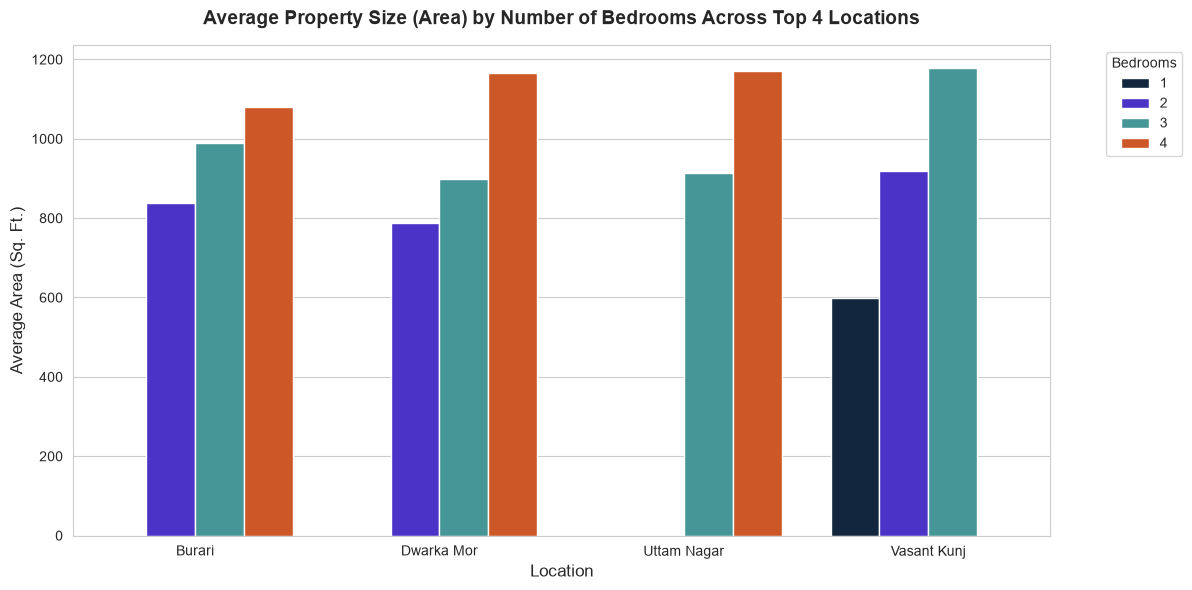

In [38]:
plt.figure(figsize=(12, 6))

with sns.axes_style("whitegrid"):
    sns.barplot(
        data=avg_area,
        x="Location",
        y="Average_Area_SqFt",
        hue="No. of Bedrooms",
        errorbar=None,
        palette=colour_palette_list,
    )

    plt.title(
        "Average Property Size (Area) by Number of Bedrooms Across Top 4 Locations",
        fontsize=14,
        fontweight="bold",
        pad=15,
    )
    plt.xlabel("Location", fontsize=12)
    plt.ylabel("Average Area (Sq. Ft.)", fontsize=12)
    plt.xticks(rotation=0)
    plt.legend(title="Bedrooms", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

The relationship between area of home and number of bedrooms is glaringly obvious from the above bar chart: the greater the number of bedrooms, the greater the property area.
Keeping the three cheaper neighbourhoods separately for the time being, it is seen that for a 2-bedroom property, Burari has an average area slightly greater than Dwarka Mor. For a similar flat in different areas, especially if the price was similar, a larger flat could be purchased more cheaply in a less expensive part of the city. The same applies to 3-bedroom homes: Dwarka Mor shows a smaller average area and Burari the greatest of the three neighbourhoods. However, for 4-bedroom homes, Burari suddenly has the smallest area. Uttam Nagar has a negligibly higher average area size than Dwarka Mor. This again is in accordance to "cheaper location = greater area of property". 
The reason for Burari bucking this trend at the 4-bedroom home level, is possibly due to a much smaller sample size.
As dealt with earlier, Uttam Nagar does not have any 2-bedroom properties as the one that it did have was filtered out of the DataFrame as it seemed to be an anomalous piece of data. The three cheapest locations don't show any 1-bedroom homes, within our price filtering range, but it is likely that they do at lower prices than our filtered DataFrame shows.
Knowing that the Vasant Kunj data has spurious data within it, the output has to be taken largely with a grain of salt. But what is seen in the graph cannot be argued with: if a 3-Bedroom home is purchased there, it will be a similar-sized flat to a 4-bedroom place in the other three locations and similarly, for a 2-bedroom flat the area is in the same region as a 3-bedroom property in a less salubrious neighbourhood. In fact, Vasant Kunj is the only place that has 1-bedroom homes, and the area of these 1-bedroom homes is in the same region as the 2-bedroom properties in Burari and Dwarka Mor. There are no 4-bedroom homes shown in the bar chart as such a property would, realistically, be well beyond the 80 Lakh price, which is the cut off price of our DataFrame.
As Vasant Kunj has a lower number of bedrooms per average home area than the other three locations, it can be presumed that the bedrooms are larger in this location, which makes it even more attractive to people on a higher income.

## 5.4 Comparative Analysis of Property Amenities Across Locations

As this study is concentrated on properties within a lower end price bracket, luxury amenities are likely to be few and far between, but it is worth checking on whether or not some of these are present.

In [39]:
high_end_amenities = {
    '24X7Security': '24 Hour Security',
    'SwimmingPool': 'Swimming Pool',
    'Gymnasium': 'Gymnasium',
    'MaintenanceStaff': 'Maintenance Staff',
    'LandscapedGardens': 'Landscaped Gardens'
}

for col_name, readable_name in high_end_amenities.items():
    nr_props = len(top4_loc[top4_loc[col_name] == 1])
    print(f"\nNumber of properties with {readable_name} = {nr_props}")
    if nr_props > 0:
        unique_locations = top4_loc[top4_loc[col_name] == 1]['Location'].unique().tolist()
        loc_string = ", ".join(unique_locations)
        print(f"Properties with a {readable_name} are found in: {loc_string}\n")
    else:
        pass


Number of properties with 24 Hour Security = 0

Number of properties with Swimming Pool = 0

Number of properties with Gymnasium = 12
Properties with a Gymnasium are found in: Uttam Nagar, Vasant Kunj


Number of properties with Maintenance Staff = 19
Properties with a Maintenance Staff are found in: Uttam Nagar, Dwarka Mor


Number of properties with Landscaped Gardens = 16
Properties with a Landscaped Gardens are found in: Vasant Kunj, Uttam Nagar, Dwarka Mor



None of the properties have 24hr security or a swimming pool. It is definitely worth ignoring these amenities from this study. A small number of properties have gymnasiums in their buildings, but these are only to be found in Uttam Nagar and Vasant Kunj. Landscaped gardens and maintenance staff are also in very small number in the study and distributed across a very small number of properties throughout Uttam Nagar, Dwarka Mor and Vasant Kunj.
As expected, properties in Burari, being less expensive than all the other areas have none of these more luxurious amenities.

Comparative analyses will be carried out on six of the most important property features: 

- Lift Availability
- Car Parking
- Resale
- Beds included (This tells whether or not beds are included in the price and is a strong indicator of whether or not the property is partly or fully furnished)
- Intercom service
- Power Backup 

As the presence of these amenities are expressed by a binary indicator, stacked bar charts will be use to display the presence/non presence of these amenities.

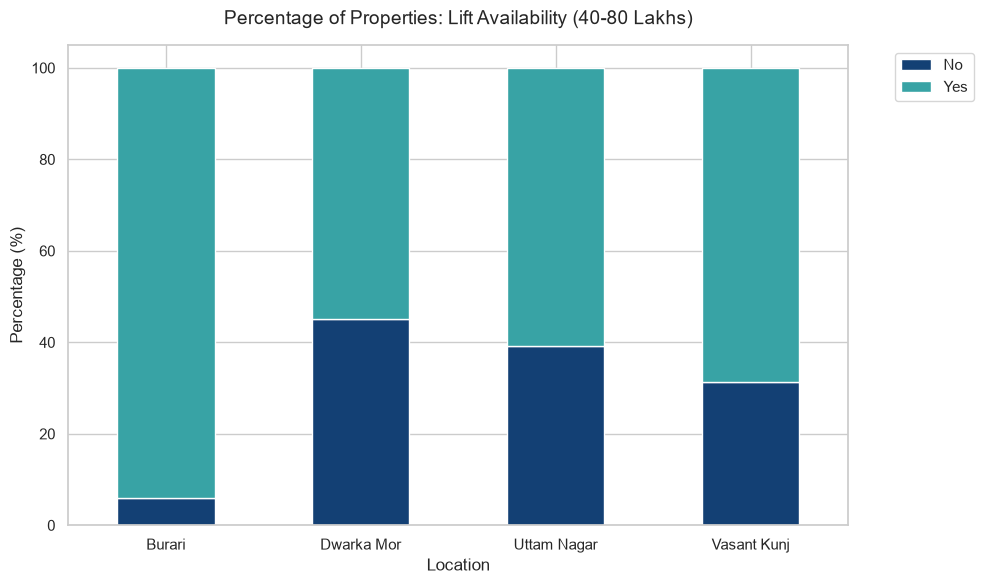

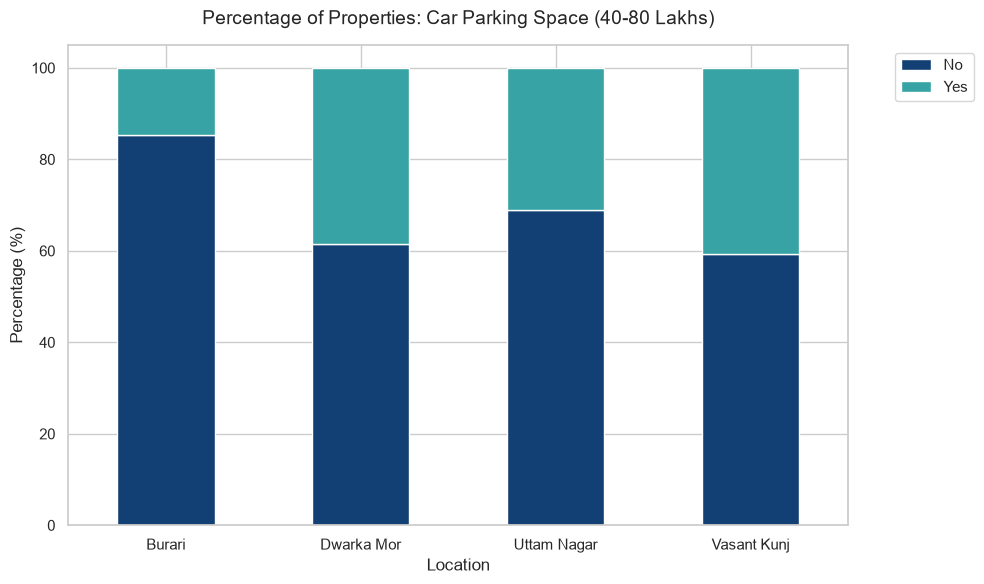

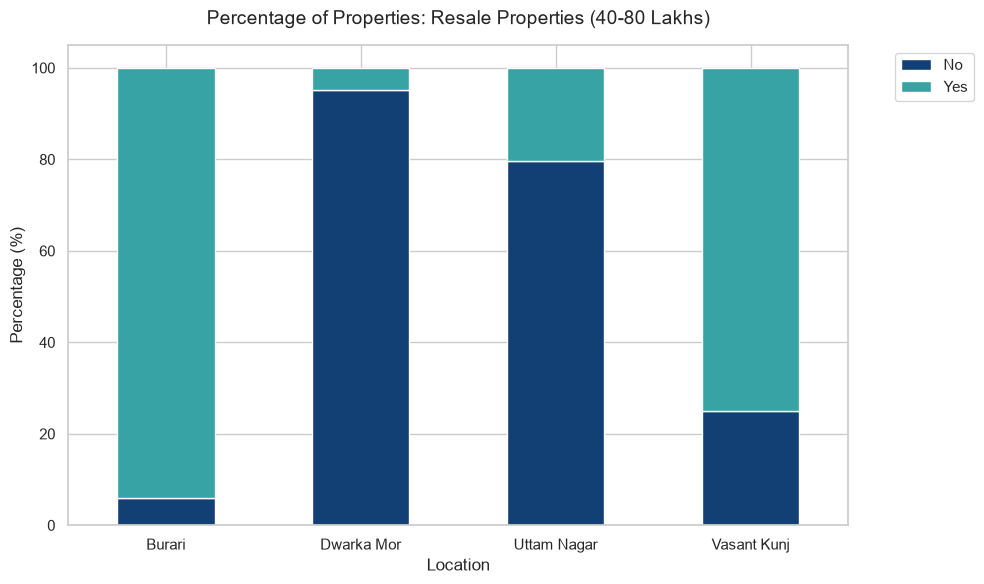

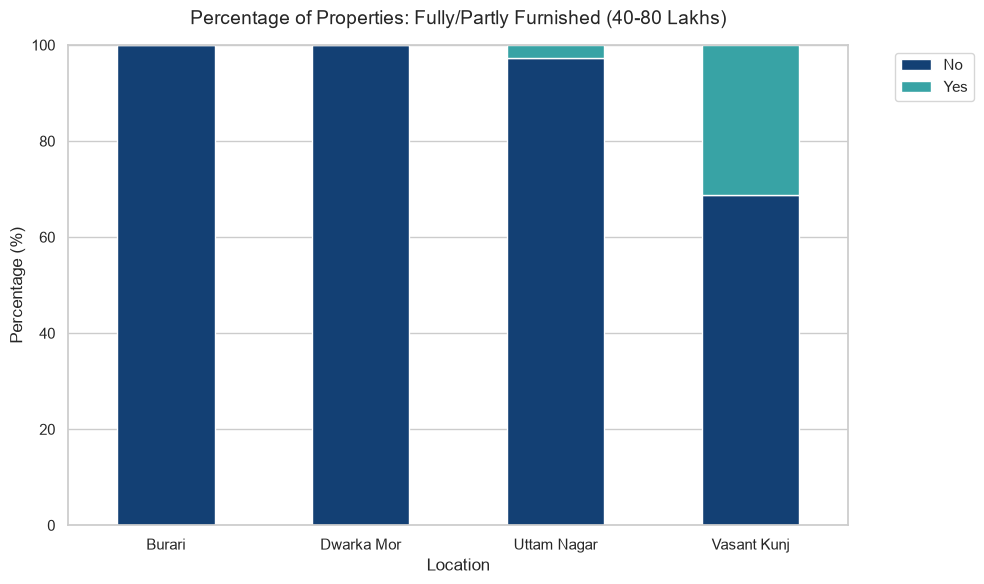

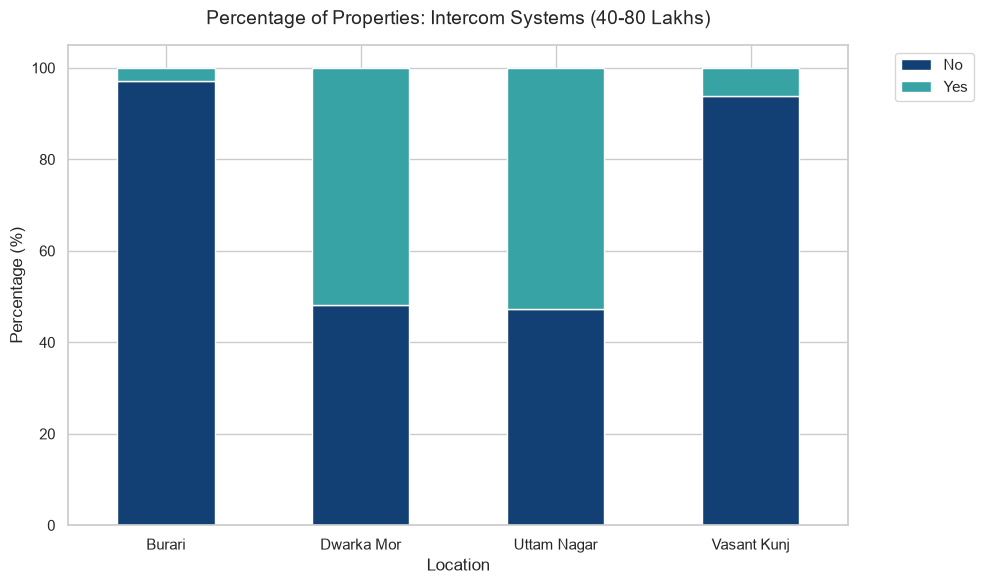

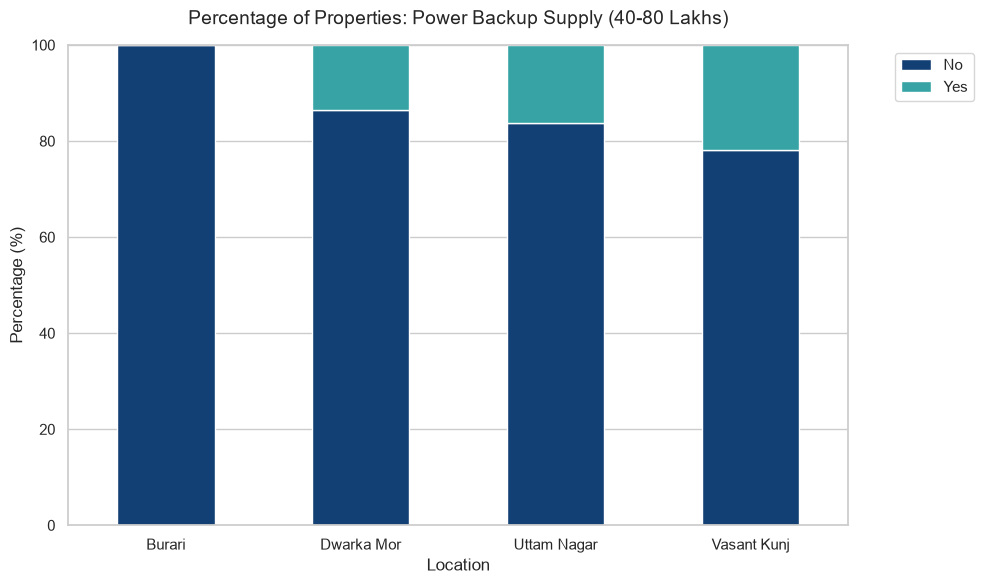

In [40]:
variables = ['LiftAvailable', 'CarParking', 'Resale', 'BED', 'Intercom', 'PowerBackup']
title_mapping = {
    'LiftAvailable': 'Lift Availability',
    'CarParking': 'Car Parking Space',
    'Resale': 'Resale Properties',
    'BED': 'Fully/Partly Furnished',
    'Intercom': 'Intercom Systems',
    'PowerBackup': 'Power Backup Supply'
}

for v in variables:
    amenity_data = pd.crosstab(
        top4_loc['Location'], 
        top4_loc[v], 
        normalize='index'
    ) * 100

    sns.set_theme(style="whitegrid")
    ax = amenity_data.plot(
        kind='bar', 
        stacked=True, 
        figsize=(10, 6), 
        color=['#134074', '#38A3A5'] 
    )


    clean_title = title_mapping.get(v, v) 
    plt.title(f'Percentage of Properties: {clean_title} (40-80 Lakhs)', fontsize=14, pad=15)
    plt.xlabel('Location', fontsize=12)
    plt.ylabel('Percentage (%)', fontsize=12)
    plt.xticks(rotation=0)

    plt.legend(['No', 'Yes'], bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

1) Lift Availability...

For the three cheapest neighbourhoods, there is a clear trend: as the location becomes more expensive, there is less chance that the building has a lift. Around 95% of properties in Burari are in buildings with a lift, about 61% in Uttam Nagar and around 55% in Dwarka Mor. 
Vasant Kunj properties have approximately a 68% chance of being in buildings with a lift. Possible reasoning for this is because at the prices that homes command there many more amenities would be expected to be included in the price, but it must be addressed that rogue data has probably overshadowed the true percentage of homes that have access to a lift.

2) Car Parking...

Car Parking is an amenity of high value, especially in a big metropolis where car parking spaces are in short supply. Accordingly, there is a connection to presence of car parking facilities and it the percentage likelihood of having this feature increases as the overall value of the location increases: Burari (15%), Uttam Nagar (30%), Dwarka Mor (approx. 38%).
Vasant Kunj, with its spurious data, has 40% car parking spaces for approx. 40% of its properties, yet it is highly likely that the true figure is a lot higher, especially if estate agents are falsely advertising that their properties are in Vasant Kunj in order to garner attention to their properties.

3) Resale Properties...

Concentrating on the least expensive locations to begin with, the trend is simply: as the location becomes higher value, the number of resale properties decreases. A staggering 95% of properties in Burari are resale homes, this drops significantly for properties in Uttam Nagar (20%). In Dwarka Mor only 5% of properties are resales.
In Vasant Kunj, 75% of the homes are resales.

4) Fully/Partly Furnished Properties...

Very simply put, there are no furnished properties in Burari or Dwarka Mor. In Uttam Nagar, there seems to be around 2 or 3% of the homes that are furnished. The figure for Vasant Kunj is a little above 30%, although due to possible data pollution, this cannot be taken as a verifiable figure.

5) Intercom systems...

Only around 2% of properties in Burari have an intercom service, yet Uttam Nagar and Dwarka Mor homes with an intercom service sit very slightly above the 50% mark. There is a possible effect where an increase in location value increases the chances of an intercom system being included in the price, yet this cannot be stated with complete confidence as both of these locations show an almost exact percentage of homes with this feature. Uttam Nagar has what could even be 1% more of its homes provided with an intercom service than Dwarka Mor. Although this is an extremely small difference, it goes against the earlier claim that wealthier neighbourhoods are more likely to possess this feature. 
Vasant Kunj, again, shows a figure of only 5%. If intercom systems are found more in homes in wealthier locations, then this could hint at the strong possibility that the listings for homes in Vasant Kunj are actually found in much less luxurious locations.

6) Power backup supply...

In the cheapest location (Burari) this feature does not exist, yet in Uttam Nagar approx. 16% of the homes have power backup facilities, in Dwarka Mor 13% of homes have it and in Vasant Kunj the figure is around 22%. Although it is slightly more prevalent in Uttam Nagar than in Dwarka Mor (a slightly less downmarket location), it can be said that overall, the likelihood of a property having power backup increases as the location value increases.

## 5.5 Distribution of Prices in Relation to Essential Amenities

Now the focus will be placed upon the two locations which have the largest datasetst: Uttam Nagar and Dwarka Mor. As Seaborn box plots will be used to compare the price premiums for the same features that were looked at in the above stacked bar charts, it will be extremely useful to create a colour palette that contains location/colour in a dictionary so that the colour relating to each location is the same for all of the boxplots (Seaborn has a tendency to flip the colours around between charts and this could add unnecessary confusion).
Similarly, the order of the locations in the legend should be kept constant. Setting the location order as a list, in this case "location_order" which can be used in the setting of the box plots will achieve this.

In [41]:
colour_palette_premiums =  {'Dwarka Mor': "#38A3A5", 'Uttam Nagar': '#EC0303'}
location_order = ['Uttam Nagar', 'Dwarka Mor']


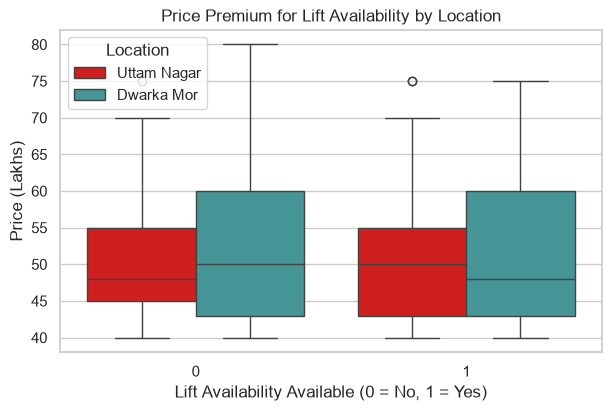

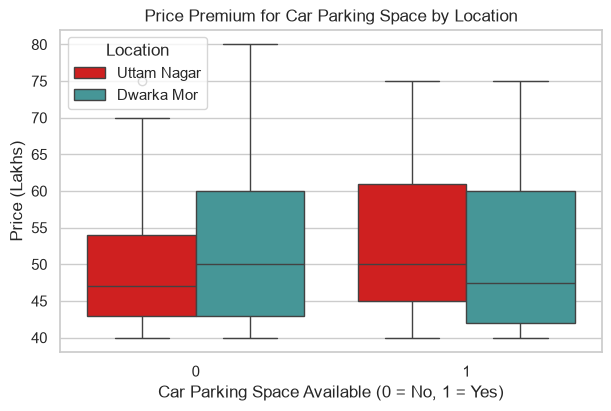

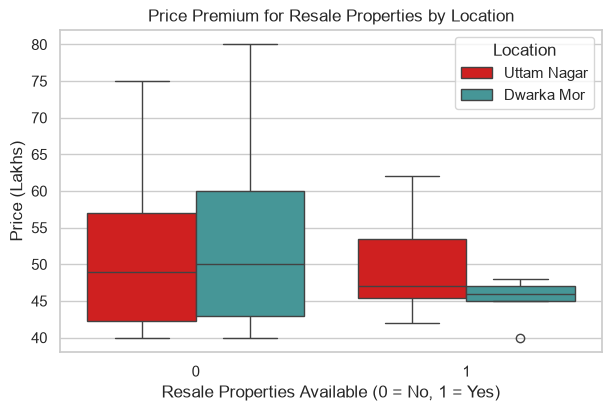

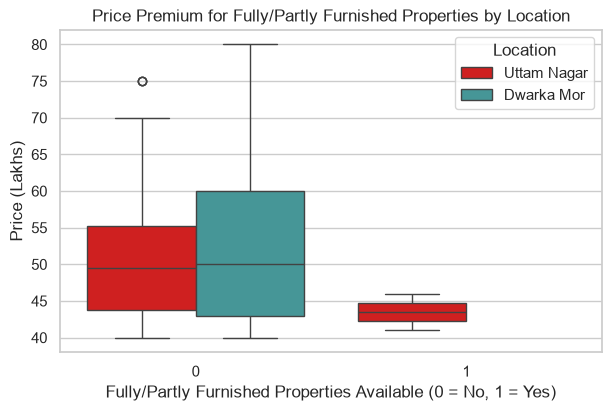

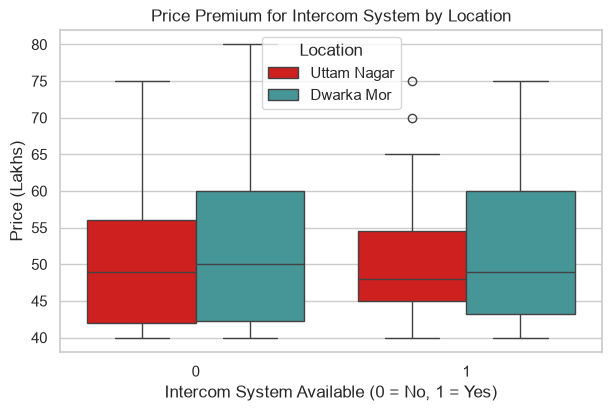

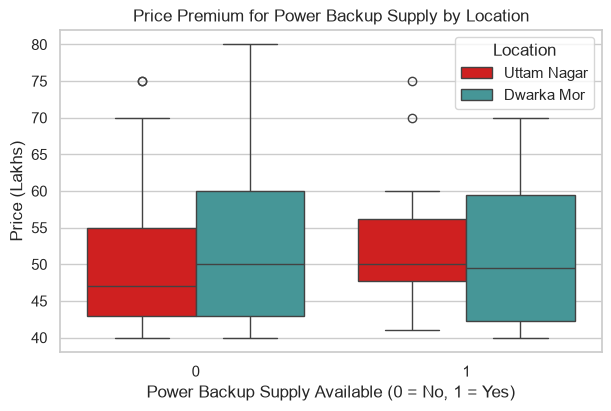

In [42]:
filtered_df = top4_loc[top4_loc['Location'].isin(['Uttam Nagar', 'Dwarka Mor'])]
amenities = ['LiftAvailable', 'CarParking', 'Resale', 'BED', 'Intercom', 'PowerBackup']
title_mapping = {
    'LiftAvailable': 'Lift Availability',
    'CarParking': 'Car Parking Space',
    'Resale': 'Resale Properties',
    'BED': 'Fully/Partly Furnished Properties',
    'Intercom': 'Intercom System',
    'PowerBackup': 'Power Backup Supply'
}
 
for n in amenities:
    clean_title = title_mapping.get(n, n)
    plt.figure(figsize=(6, 4), layout="constrained")
    sns.boxplot(data=filtered_df, 
                x=n, 
                y='Price (Lakhs)', 
                hue='Location', 
                palette=colour_palette_premiums,
                hue_order=location_order,
                )
    plt.title(f"Price Premium for {clean_title} by Location")
    plt.xlabel(f"{clean_title} Available (0 = No, 1 = Yes)")
    plt.ylabel('Price (Lakhs)')
    plt.show()

1) Lift Availability...

It is quite clear that whether a building has a lift makes only the tiniest amount of difference to the property prices. In the case of Uttam Nagar the lower quartile is lower when there is a lift, the upper quartiles equal, but there is a slight skewing towards the higher values. The overall span of the box plots and its whiskers is the same, but there is an outlier property with a lift whose price sits well outside of the distribution range at 75 Lakhs.
Conversely, in Dwarka Mor, the box plot reaches a maximum price of 80 Lakhs in buildings without a lift, but where there is a lift present, the maximum price is 75 Lakhs and the interquartile range (IQR) shows a very slight skewing towards the lower house values. 

2) Car Parking...

In the case of Uttam Nagar, the existence of car parking facilities leads to an increase of the lower quartile and median value by 2-3 Lakhs, yet the upper quartile value increases by about 7 Lakhs.The maximum prices increases from 70 to 75 Lakhs. 
Again, properties in Dwarka Mor show slight unexpected results: the IQR increases very slightly, but this is because of a slight lowering of the lower quartile by about 1 Lakh. the box shows a slight skewing to the lower price values. The maximum value of a property without car parking facilities drops from 80 Lakhs to 75 Lakhs for properties with parking.

3) Resale Properties...

This is a feature that shows the most clearly, so far, its effect on housing prices. 
In Uttam Nagar, the maximum price falls significantly from 75 Lakhs for a new-build to around 62 Lakhs for a resale property. Although the minimum house price increases slightly for a resale, the box itself shows a skewing towards the lower prices. 
This is even more staggering in the case of Dwarka Mor: the maximum price drops from 80 Lakhs for a new-build to 48 Lakhs for a resale home, and the resale box itself is highly compressed, with its IQR being at almost the same level as the lower quartile of a new-build home. There is also an outlier property at 40 Lakhs.

4) Fully/Partly Furnished Properties...

Here, there is only comparable data for Uttam Nagar as all the properties in Dwarka Mor are unfurnished. 
There is a highly visible decrease in property value in furnished homes. This is unexpected as a furnished property would be considered more valuable. The maximum value on the unfurnished home's box plot is 70 Lakhs (there is also an outlier of 75 Lakhs), yet the max furnished property price is 46 Lakhs. The IQR of the furnished box plot is more or less below the lower quartile of the unfurnished box plot (The upper quartile of the furnished box plot is just 1 Lakh above the lower quartile of the unfurnished box plot and the median is level with the lower quartile).
This strange trend could possibly be explained by home owners who are trying to resell their property including furniture in the deal as an incentive for the buyer to buy a resale property.

5) Properties with an Intercom Service...

An intercom service has a very weak effect on the price of a home. The box plots of both locations show a decrease in the upper fence property values in properties that have an intercom service. The price drops by 10 Lakhs in the case of Uttam Nagar and by 5 Lakhs for properties in Dwarka Mor. However, there are two outliers in Uttam Nagar: one at 75 Lakhs and one at 70 Lakhs. The box plots in properties which have an intercom have a skewing towards the lower house prices.
The only signs of an increase are the lower quartile of Uttam Nagar, which increases from 42 Lakhs (for a property without an intercom service) to 45 Lakhs for a property with one.

6) Properties With a Power Backup Supply...

In the case of Uttam Nagar, the IQR for a property with power backup shifts up slightly (especially in its lower quartile, which increases from 43 to 48 Lakhs), while the upper fence price drops from 70 down to 60 Lakhs. The lower fence value increases by 1 Lakh for a property with power backup. Both sides feature an outlier at 75 Lakhs
The box plots of Dwarka Mor show little change, except that the upper fence price for a property without backup falls from 80 Lakhs to 70 Lakhs for a property with power backup.

# 6. Multiple Linear Regression Analysis for Select Locations

## 6.1 Bivariate Baseline Analyses

In the previous section, the boxplots showed whether or not a feature had an influence on house prices in both of our locations. In some examples the influence was obvious, in others it was very slight or even ambiguous. To see the real state of things further, more thorough analyses will be carried out to see if there is any statistical back up to what has already been deduced from visual inspection. This will lead on to the creation of statistical models that will be able to predict house prices based on setting specific property criteria.

Firstly, the exact relationship will be examined between property prices and area of properties. The regression plots will allow for a visual understanding and statistical testing will give specific mathematical truths of the relationships.

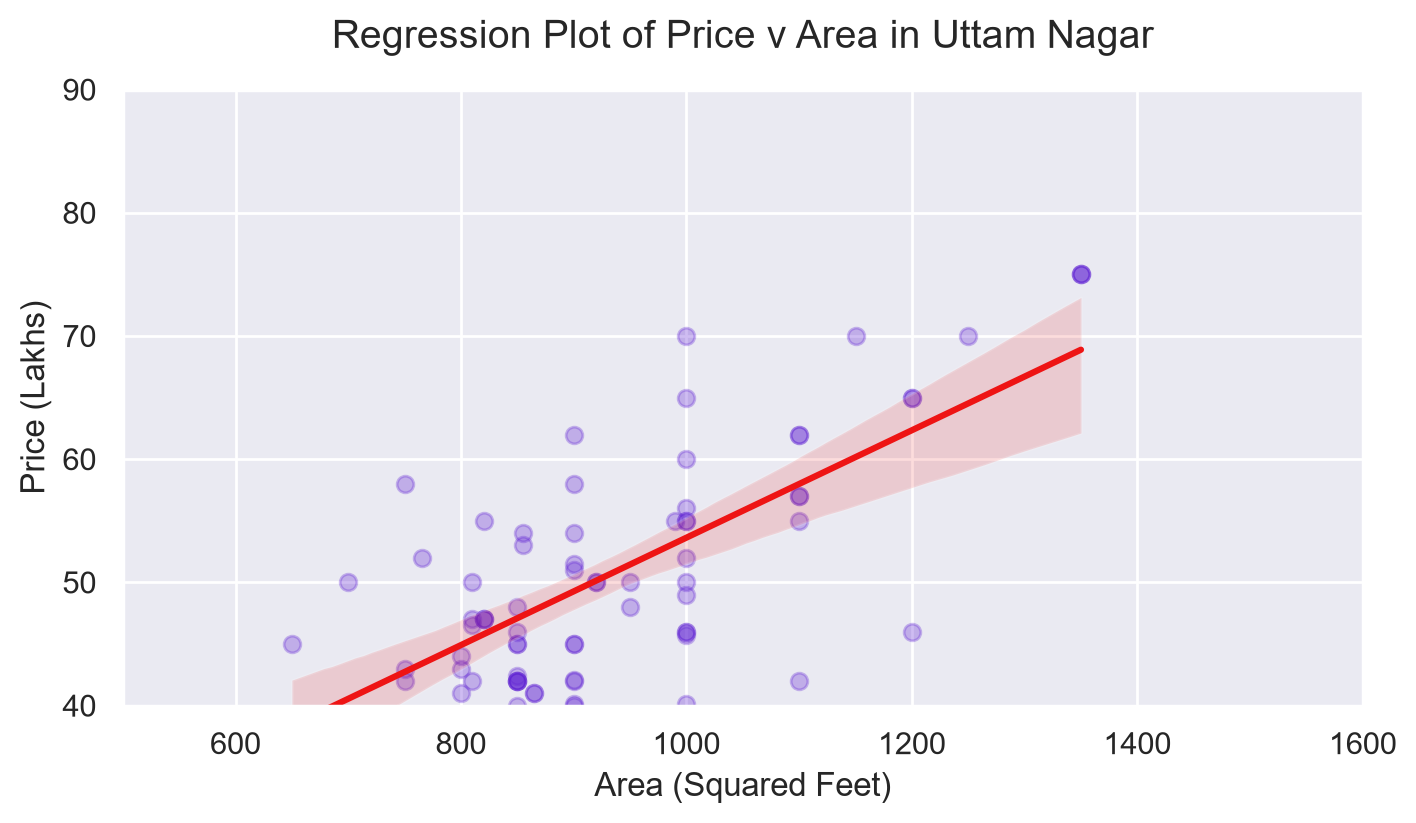

STATISTICAL BASELINE FOR UTTAM NAGAR 
R-squared Score  : 0.4931
Area Coefficient : 0.0436
t-statistic      : 8.3697
p-value          : 0.00000000




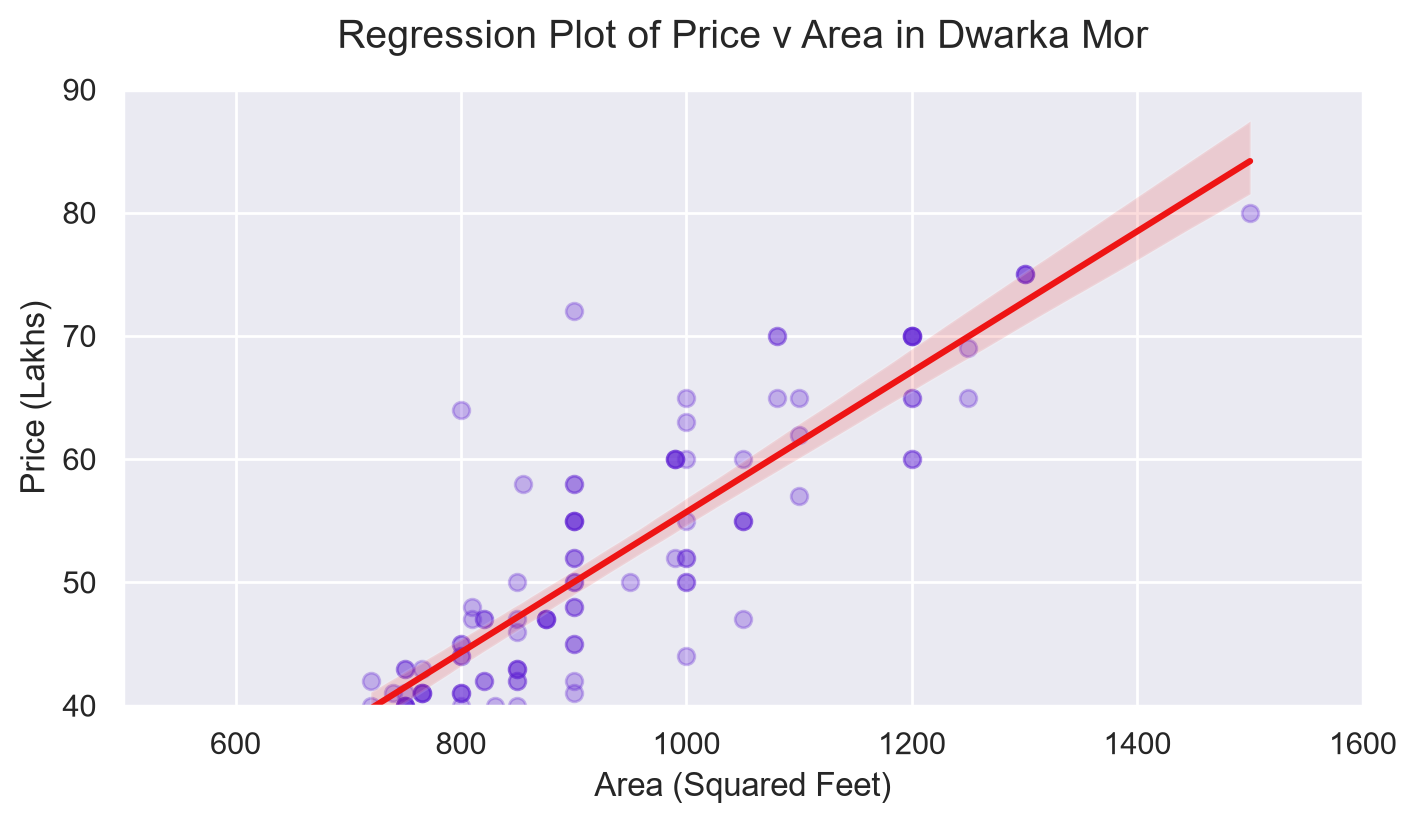

STATISTICAL BASELINE FOR DWARKA MOR 
R-squared Score  : 0.7541
Area Coefficient : 0.0570
t-statistic      : 17.6874
p-value          : 0.00000000




In [43]:
top2_loc = ['Uttam Nagar', 'Dwarka Mor']

for loc in top2_loc:
    plt.figure(figsize=(8,4), dpi=200)
    with sns.axes_style('darkgrid'):
        ax = sns.regplot(
            data=top4_loc[top4_loc['Location'] == loc],
            x='Area',
            y='Price (Lakhs)',
            color="#6022d4",
            scatter_kws = {'alpha': 0.3},
            line_kws = {'color': "#ee1414"}
        )
        plt.title(f'Regression Plot of Price v Area in {loc}', fontsize=14, pad=15)
        ax.set(
            ylim=(40, 90),
            xlim=(500, 1600),
            ylabel='Price (Lakhs)',
            xlabel='Area (Squared Feet)'
        )
    
    plt.show() 
    
    stat_test_loc = top4_loc[top4_loc['Location'] == loc]
    X = stat_test_loc['Area']
    Y = stat_test_loc['Price (Lakhs)']
    X_with_constant = sm.add_constant(X)
    
    model = sm.OLS(Y, X_with_constant).fit()
    
    print("="*60)
    print(f"STATISTICAL BASELINE FOR {loc.upper()} ")
    print("="*60)
    print(f"R-squared Score  : {model.rsquared:.4f}")
    print(f"Area Coefficient : {model.params['Area']:.4f}")
    print(f"t-statistic      : {model.tvalues['Area']:.4f}")
    print(f"p-value          : {model.pvalues['Area']:.8f}")
    print("="*60 + "\n\n")


A quick glance at the regression plots confirms the obvious positive relationship between area and property price (i.e. the bigger a home gets, the more expensive it becomes). Dwarka Mor, the slightly more expensive location, has a steeper regression line. This implies that the price increases at a faster rate the larger a home is.

Understanding the statistical tests

1) Uttam Nagar...
R-squared Score  : 0.4931
This is very strong in terms of real estate data. It assumes that 49.31% of the property prices in Uttam Nagar are explained solely by area of property.
Area Coefficient : 0.0436
This is the property pricing multiplier. In this case it can be interpreted as every extra square foot of property adding 0.0436 Lakhs (4360 rupees).
t-statistic      : 8.3697
This is above 2, so indicates that area is a strong driver of property pricing in Uttam Nagar.
p-value          : 0.00000000
This is well below the 0.05 confidence limit, so backs up the finding that area affects house prices with absolute certainty.

2) Dwarka Mor...
R-squared Score  : 0.7541
This is even stronger that for Uttam Nagar. Here, 75.41% of the property prices are influenced by their sizes.

Area Coefficient : 0.0570
Unsurprisingly, as the higher r-squared value is higher, so is the area coefficient. In this case, an increase in area by just one square foot leads to a property price increase of 0.0570 Lakhs (5700 rupees) in Dwarka Mor.
t-statistic      : 17.6874
Again, A much higher t-statistic shows just how strong a driver of price the property area is in Dwarka Mor.
p-value          : 0.00000000
With absolute confidence, once more, this strong relationship between area and price is not due to any fluke.

## 6.2 Multivariate Model Expansion

The two multivariate regression models that were created were:

1) Dwarka Mor


$$
\begin{aligned}
\ln(\text{Price}) = \beta_0 &+ \beta_1(\text{Area}) + \beta_2(\text{No. of Bedrooms}) + \beta_3(\text{Resale}) + \beta_4(\text{Car Parking}) \\
&+ \beta_5(\text{Lift Available}) + \beta_6(\text{Power Backup}) + \beta_7(\text{Intercom}) + \epsilon
\end{aligned}
$$


2) Uttam Nagar


$$ \ln(\text{Price}) = \beta_0 + \beta_1(\text{Area}) + \beta_2(\text{No. of Bedrooms}) + \beta_3(\text{Resale}) + \beta_4(\text{Car Parking}) + \beta_5(\text{Lift Available}) + \epsilon $$

*Where:*
* $\beta_0$ represents the model intercept (the baseline constant).
* $\beta_1 \dots \beta_7$ represent the calculated feature coefficients.
* $\epsilon$ represents the residual error term.

These feature variables map directly to our exact DataFrame column strings as follows:


• ln(Price) -> Log-transformed target variable derived from df['Price (Lakhs)']\
• Area -> df['Area']\
• Bedrooms -> df['No. of Bedrooms']\
• Resale -> df['Resale']\
• Car Parking -> df['CarParking']\
• Lift Available -> df['LiftAvailable']\
• Power Backup -> df['PowerBackup']\
• Intercom -> df['Intercom']

To prepare for the multivariate regression models, a DataFrame needs to be created for each location.

In [44]:
dwarka_mor = top4_loc[top4_loc['Location'] == 'Dwarka Mor']
uttam_nagar = top4_loc[top4_loc['Location'] == 'Uttam Nagar']

For conducting a functional multiple regression model, it useful to follow the rule of 15 samples per variable. The number of rows per DataFrame needs to be reconfirmed:

In [45]:
nr_rows_dwarka = dwarka_mor.shape[0]
nr_rows_uttam = uttam_nagar.shape[0]

print(f"Number of properties in Dwarka Mor: {nr_rows_dwarka}")
print(f"Number of properties in Uttam Nagar: {nr_rows_uttam}")

Number of properties in Dwarka Mor: 104
Number of properties in Uttam Nagar: 74


In [46]:
nr_variables_dwarka = round(104 / 15, 1)
nr_variables_uttam = round(74 / 15, 1)

print(f"The number of variables that can be used in multiple regression model of Dwarka Mor: {nr_variables_dwarka}")
print(f"The number of variables that can be used in multiple regression model of Dwarka Mor: {nr_variables_uttam}")

The number of variables that can be used in multiple regression model of Dwarka Mor: 6.9
The number of variables that can be used in multiple regression model of Dwarka Mor: 4.9


As both results yield a fractional value ending in .9, they were rounded to the nearest whole integer above (7 for Dwarka Mor and 5 for Uttam Nagar) to establish the maximum number of predictor variables for each multivariate regression. This rounding approach ensures that the localized models maintain a robust sample-to-variable ratio close to the standard 15:1, which will permit an adequately effective multiple regression analysis.

### 6.2.1 Multivariate Regression of Dwarka Mor

Dwarka Mor contains the largest sample size (104 properties). 
As previously stated, 7 independent feature variables can be used safely in the regression model, which follows the sample-to-variable ratio of 15:1. Specifically, the structural and amenity variables that will be used are:
#
- Area
- Number of Bedrooms
- Resale
- Lift Available
- Car Parking
- Intercom
- Power Backup

To prepare the Dwarka Mor dataset for multiple linear regression, the variables were first separated into the dependent target variable (Price (Lakhs)) and the seven selected independent feature attributes. The data was then split 80/20 into training and testing sets. This allocated 80% of the observations for model training and 20% for testing, thus ensuring that the model can be evaluated objectively on unseen test data. To guarantee the reproducibility of the split, a fixed random_state was applied.

In [47]:
target_dwarka = dwarka_mor['Price (Lakhs)']
features_dwarka = dwarka_mor[['Area', 'No. of Bedrooms', 'Resale', 'LiftAvailable', 'CarParking', 'Intercom', 'PowerBackup']]

X_train_dwarka, X_test_dwarka, y_train_dwarka, y_test_dwarka = train_test_split(features_dwarka, 
                                                    target_dwarka, 
                                                    test_size=0.2, 
                                                    random_state=10)

To check that the dataset was split correctly, a validation check was carried out to calculate the exact distribution of rows. Printing the proportions confirms that the training and testing subsets actually follow the 80/20 split.

In [48]:
train_pct = 100*len(X_train_dwarka)/len(features_dwarka)
print(len(X_train_dwarka))
print(len(features_dwarka))
print(f'Training data is {train_pct:.3}% of the total data.')

print(X_test_dwarka.shape)
print(features_dwarka.shape)

test_pct_dwarka = 100*X_test_dwarka.shape[0]/features_dwarka.shape[0]
print(f'Test data makes up the remaining {test_pct_dwarka:0.3}%.')

83
104
Training data is 79.8% of the total data.
(21, 7)
(104, 7)
Test data makes up the remaining 20.2%.


The datasets have now been prepared and verified and the multiple linear regression model for Dwarka Mor was initialized and fitted using the training data. After training, the R-squared value was calculated for the training data to evaluate how confidently the seven feature variables explain the variance in property prices.

In [49]:
regr_dwarka = LinearRegression()
regr_dwarka.fit(X_train_dwarka, y_train_dwarka)
rsquared_dwarka = regr_dwarka.score(X_train_dwarka, y_train_dwarka)

print(f'Training data r-squared: {rsquared_dwarka:.2}')

Training data r-squared: 0.8


This R-squared value of 0.8 demonstrates that 80% of price variability in the Dwarka Mor housing market is due to the effects of these seven chosen feature variables.

After the linear regression model has been successfully fitted to the Dwarka Mor training dataset, the mathematical weights connected to each of the feature variables must be established. These will be presented in a pandas DataFrame.

In [50]:
regr_coef_dwarka = pd.DataFrame(data=regr_dwarka.coef_, index=X_train_dwarka.columns, columns=['Coefficient'])
regr_coef_dwarka

,Coefficient
Area,0.055919
No. of Bedrooms,3.239280
Resale,1.188678
LiftAvailable,-1.780065
CarParking,1.722036
Intercom,1.122610
PowerBackup,1.997585


The coefficients listed above show the extent to which the 7 feature variables affect property prices in Dwarka Mor. Simply speaking, finding the premium for a home having an extra unit of area or a specific amenity the coefficients for that variable is multiplied by the number of units of that variable. For example, the number of bedrooms is multiplied by the coefficient (3.239280) and then added to the baseline price. For the boolean amenities (or 1), the coefficients relate to the number of lakhs which are added to the baseline property price, or (in the case of lift availability) is subtracted from it.

Below is an example, which illustrates the premium for having an extra bedroom in Dwarka Mor.

In [51]:
premium_dwarka = regr_coef_dwarka.loc['No. of Bedrooms'].values[0]
print(f'The price premium for having an extra room is ₹{premium_dwarka:.5} Lakhs')

The price premium for having an extra room is ₹3.2393 Lakhs


To assess the overall efficiency of the fitted model, it is necessary to generate the predicted pricing against the training data and check the resulting errors. The fitted regression engine is used to calculate the predicted property values for Dwarka Mor and the subsequent residuals are calculated. These represent the differences between the actual housing prices and the model's predictions.

In [52]:
predicted_vals_dwarka = regr_dwarka.predict(X_train_dwarka)
residuals_dwarka = (y_train_dwarka - predicted_vals_dwarka)

Using these calculated predicted prices and residual errors, a scattergraph can now be produced that shows the true prices (from the training data) vs. the predicted prices generated by the regression model, with a line of perfect identity (y = x) passing through all the data points. Similarly, a second scattergraph can be generated that shows the predicted prices against their corresponding residual errors, to check for any errors made by our regression model.

<>:4: SyntaxWarning: invalid escape sequence '\h'
<>:6: SyntaxWarning: invalid escape sequence '\h'
<>:12: SyntaxWarning: invalid escape sequence '\h'
<>:4: SyntaxWarning: invalid escape sequence '\h'
<>:6: SyntaxWarning: invalid escape sequence '\h'
<>:12: SyntaxWarning: invalid escape sequence '\h'
C:\Users\jhrdc\AppData\Local\Temp\ipykernel_10780\1959950073.py:4: SyntaxWarning: invalid escape sequence '\h'
  plt.title(f'Actual vs Predicted Prices: $y _i$ vs $\hat y_i$', fontsize=17)
C:\Users\jhrdc\AppData\Local\Temp\ipykernel_10780\1959950073.py:6: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel('Predicted prices 000s $\hat y _i$', fontsize=14)
C:\Users\jhrdc\AppData\Local\Temp\ipykernel_10780\1959950073.py:12: SyntaxWarning: invalid escape sequence '\h'
  plt.xlabel('Predicted Prices $\hat y _i$', fontsize=14)


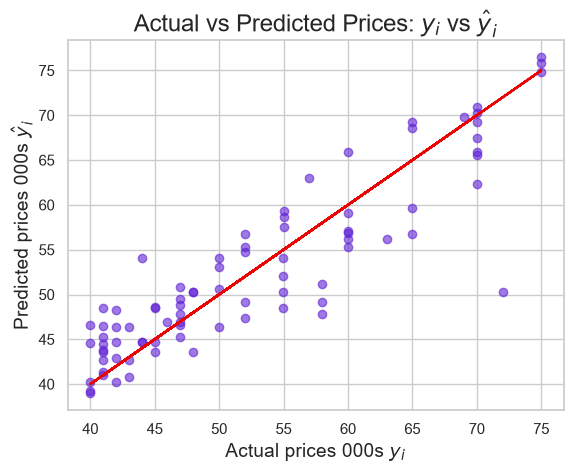

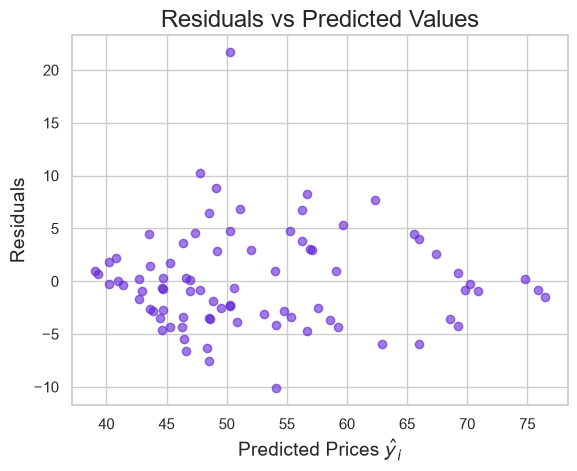

In [53]:
plt.figure(dpi=100)
plt.scatter(x=y_train_dwarka, y=predicted_vals_dwarka, c="#6022d4", alpha=0.6)
plt.plot(y_train_dwarka, y_train_dwarka, color="#EC0303")
plt.title(f'Actual vs Predicted Prices: $y _i$ vs $\hat y_i$', fontsize=17)
plt.xlabel('Actual prices 000s $y _i$', fontsize=14)
plt.ylabel('Predicted prices 000s $\hat y _i$', fontsize=14)
plt.show()

plt.figure(dpi=100)
plt.scatter(x=predicted_vals_dwarka, y=residuals_dwarka, c="#6022d4", alpha=0.6)
plt.title('Residuals vs Predicted Values', fontsize=17)
plt.xlabel('Predicted Prices $\hat y _i$', fontsize=14)
plt.ylabel('Residuals', fontsize=14)
plt.show()

The first scatter graph (Actual vs. Predicted Prices), shows the data points clustering closely to the line of perfect identity. This demonstrates the model's high level of efficiency, as the predicted prices accord closely with the actual market prices. An interest feature that deserves a mention is the vertical stacking of data points at specific intervals along the X-axis (seemingly in Lakh increments). It is quite evident that market prices are rounded to the nearest Lakh prior to being put onto the marketplace.

In the second chart (Residuals vs. Predicted Values), the error distribution shows that the regression model is operating in a healthy manner. There is only one prominent outlier property, where the predicted price is just over 20 Lakhs above the zero-error line value. All other residuals, are scattered evenly on either side of the zero-error line. The model seems to be more accurate for predicting prices at the higher and lower ends of the price brackets, as the residuals are much closer to the zero-error line.

To investigate the prediction errors further, the statistical shape of the residual distribution needs to be measured formally. 
Firstly, the exact mean and skewness scores of the residuals are calculated and then plotted on a histogram with a Kernel Density Estimate (KDE) line overlaying it. This allows the shape of the distribution to be visualised and, together with the skewness scores, it can be established just how close to a normal distribution the curve is.

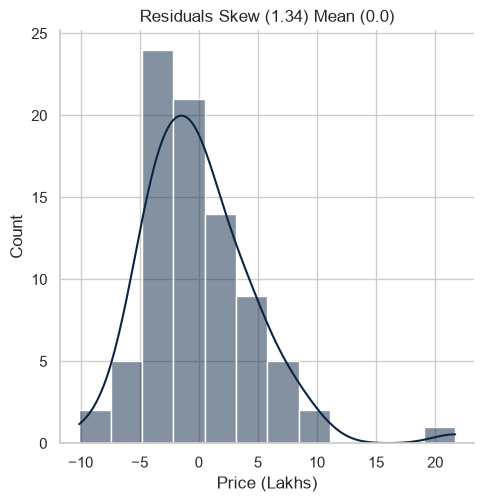

In [54]:
resid_mean_dwarka = round(residuals_dwarka.mean(), 2)
resid_skew_dwarka = round(residuals_dwarka.skew(), 2)

sns.displot(residuals_dwarka, kde=True, color='#0B2545')
plt.title(f'Residuals Skew ({resid_skew_dwarka}) Mean ({resid_mean_dwarka})')
plt.show()

The distribution plot generated shows the shape and statictical behaviour of the model's residuals. The mean of these residuals is 0.0, and this confirms that the regression line sits perfectly centred in the dataset and balances residuals that have been predicted to be over and under the real price. Most of the errors are located in the -5 to +5 Lakhs margin, which laregly show the accuracy of the model in predicting pricing in Dwarka Mor.
The curve itself does not follow a perfect bell shape: it is skewed to the right and has a skewness score of 1.34. The trailing tail, which extends to the right side of the graph, has probably been a result of the outlier, which was under-estimated by 20 Lakhs.

Linear regression models perform best when the target data follows a fairly symmetric, normal bell curve. So the distribution of our target variables ("Price (Lakhs")) needs to be analysed. The further it moves from a normal bell curve, the more it can compromise the reliability of our predictive regression model.
Again, the skewness of the data will be calculated and a Seaborn displot will be used to generate a histogram of the prices , with a Kernel Density Estimate (KDE) line on top of the histogram.

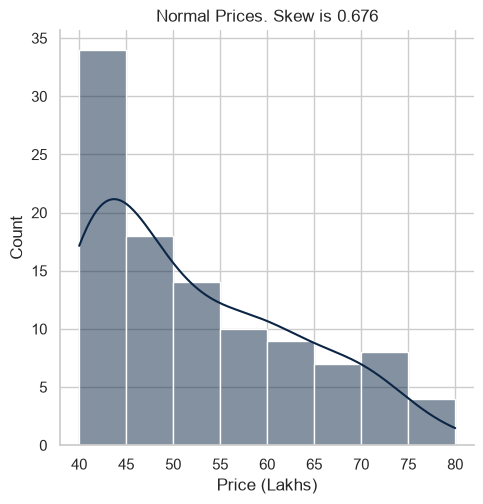

In [55]:
tgt_skew_dwarka = dwarka_mor['Price (Lakhs)'].skew()
sns.displot(dwarka_mor['Price (Lakhs)'], kde='kde', color='#0B2545')
plt.title(f'Normal Prices. Skew is {tgt_skew_dwarka:.3}')
plt.show()

The skewness of the data is 0.676. Whenever possible, the skewness needs to get as close to zero as it possibly can. This can be achieved by conducting a logarithmic data transformation.

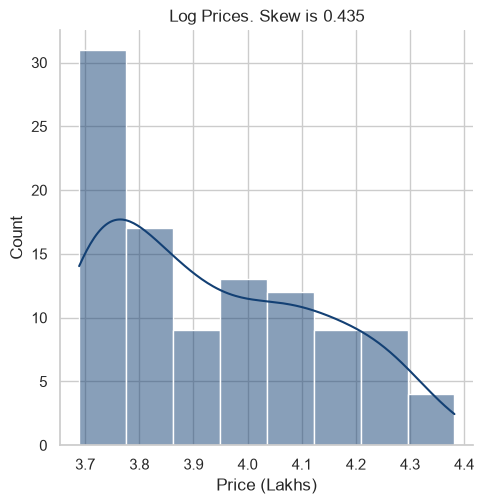

In [56]:
y_log_dwarka = np.log(dwarka_mor['Price (Lakhs)'])
sns.displot(y_log_dwarka, kde=True, color='#134074')
plt.title(f'Log Prices. Skew is {y_log_dwarka.skew():.3}')
plt.show()

Transforming our target ("Price (Lakhs)") using the log scale, the skewness has been decreased to 0.435 and it looks visually closer to a bell curve. This data transformation will be incorporated into the multiple regression model.

Using the natural log of the property prices, the multiple linear regression model will be constructed again, substituting the original target variable with the log-transformed price.

In [57]:
new_target_dwarka = np.log(dwarka_mor['Price (Lakhs)'])
features = dwarka_mor[['Area', 'No. of Bedrooms', 'Resale', 'LiftAvailable', 'CarParking', 'Intercom', 'PowerBackup']]

X_train_dwarka, X_test_dwarka, log_y_train_dwarka, log_y_test_dwarka= train_test_split(features, 
                                                    new_target_dwarka, 
                                                    test_size=0.2, 
                                                    random_state=10)

log_regr_dwarka = LinearRegression()
log_regr_dwarka.fit(X_train_dwarka, log_y_train_dwarka)
log_rsquared_dwarka = log_regr_dwarka.score(X_train_dwarka, log_y_train_dwarka)

log_predictions_dwarka = log_regr_dwarka.predict(X_train_dwarka)
log_residuals_dwarka = (log_y_train_dwarka - log_predictions_dwarka)

print(f'Training data r-squared: {log_rsquared_dwarka:.2}')

Training data r-squared: 0.79


Using the natural log of the property prices gives an R-squared value of 0.79, which is only 0.01 less than the value before the log scale was applied (0.8). However, this is an excellent compromise as using log(price) the skewness was greatly reduced, thus aiding the creation of a more effective regression model and the R-squared value stayed more or less the same.

Next, the coefficients need to be calculated again to examine how the features affect the log-transformed property prices.

In [58]:
df_coef_dwarka = pd.DataFrame(data=log_regr_dwarka.coef_, index=X_train_dwarka.columns, columns=['coef'])
df_coef_dwarka

,coef
Area,0.001045
No. of Bedrooms,0.047105
Resale,0.027125
LiftAvailable,-0.030776
CarParking,0.028351
Intercom,0.021329
PowerBackup,0.037021


Because this new regression model uses a log scale, these new coefficients represent the percentage change in house prices rather than the Lakh amounts. In simple terms, multiplying these decimals by 100 gives the exact percentage value each feature adds or subtracts from a home in Dwarka Mor. For example, each extra square foot of area adds 0.10% to the price, an extra bedroom adds 4.71%, car parking facilities add 2.84%, while a Lift reduces the value by 3.08%.

To visually evaluate the improvements gained by applying the log transformation, the new log regression model will be compared with the original price model.
The first two scatter graphs map the Actual vs. Predicted values for both models against a diagonal line of perfect identity. This allows for a direct comparison of the predictive efficiency and highlights how the data are distributed across the two scales. The final two graphs map the Residuals vs. Fitted Values. This side-by-side comparison allows inspection of the residual distributions and tells if using a logarithmic data transformation has improved the skewness and given a more balanced residual cloud.

<>:3: SyntaxWarning: invalid escape sequence '\h'
<>:5: SyntaxWarning: invalid escape sequence '\h'
<>:10: SyntaxWarning: invalid escape sequence '\h'
<>:12: SyntaxWarning: invalid escape sequence '\h'
<>:17: SyntaxWarning: invalid escape sequence '\h'
<>:23: SyntaxWarning: invalid escape sequence '\h'
<>:3: SyntaxWarning: invalid escape sequence '\h'
<>:5: SyntaxWarning: invalid escape sequence '\h'
<>:10: SyntaxWarning: invalid escape sequence '\h'
<>:12: SyntaxWarning: invalid escape sequence '\h'
<>:17: SyntaxWarning: invalid escape sequence '\h'
<>:23: SyntaxWarning: invalid escape sequence '\h'
C:\Users\jhrdc\AppData\Local\Temp\ipykernel_10780\1205416913.py:3: SyntaxWarning: invalid escape sequence '\h'
  plt.title(f'Actual vs Predicted Log Prices: $y _i$ vs $\hat y_i$ (R-Squared {log_rsquared_dwarka:.2})', fontsize=17)
C:\Users\jhrdc\AppData\Local\Temp\ipykernel_10780\1205416913.py:5: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel('Predicted Log Prices $\hat y _i$', fo

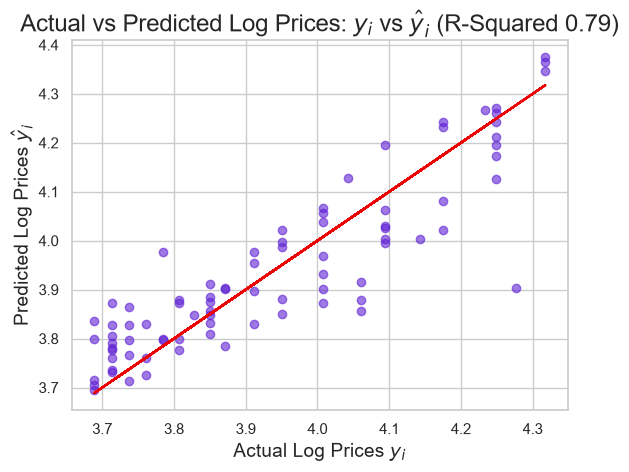

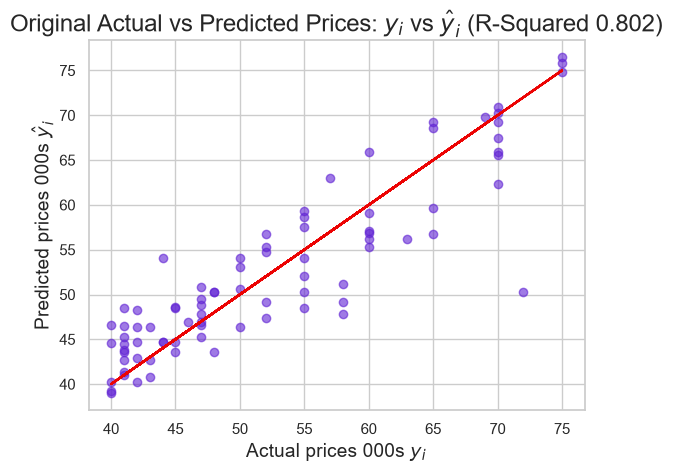

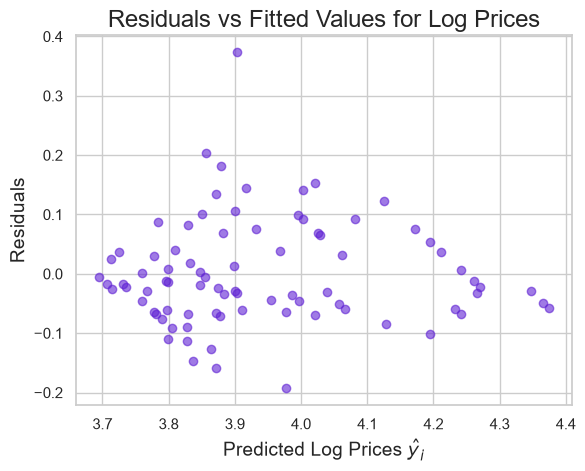

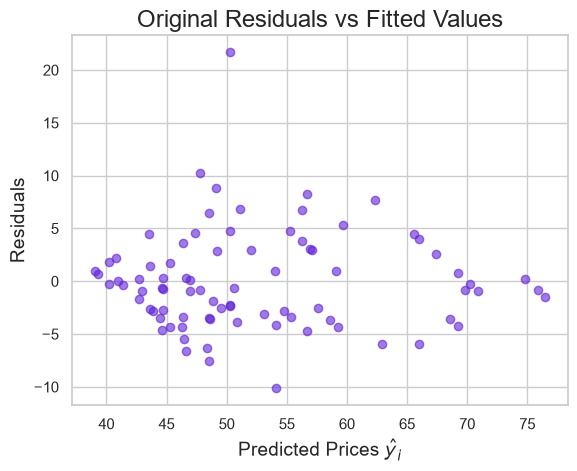

In [59]:
plt.scatter(x=log_y_train_dwarka, y=log_predictions_dwarka, c="#6022d4", alpha=0.6)
plt.plot(log_y_train_dwarka, log_y_train_dwarka, color='#EC0303')
plt.title(f'Actual vs Predicted Log Prices: $y _i$ vs $\hat y_i$ (R-Squared {log_rsquared_dwarka:.2})', fontsize=17)
plt.xlabel('Actual Log Prices $y _i$', fontsize=14)
plt.ylabel('Predicted Log Prices $\hat y _i$', fontsize=14)
plt.show()

plt.scatter(x=y_train_dwarka, y=predicted_vals_dwarka, c="#6022d4", alpha=0.6)
plt.plot(y_train_dwarka, y_train_dwarka, color='#EC0303')
plt.title(f'Original Actual vs Predicted Prices: $y _i$ vs $\hat y_i$ (R-Squared {rsquared_dwarka:.3})', fontsize=17)
plt.xlabel('Actual prices 000s $y _i$', fontsize=14)
plt.ylabel('Predicted prices 000s $\hat y _i$', fontsize=14)
plt.show()

plt.scatter(x=log_predictions_dwarka, y=log_residuals_dwarka, c="#6022d4", alpha=0.6)
plt.title('Residuals vs Fitted Values for Log Prices', fontsize=17)
plt.xlabel('Predicted Log Prices $\hat y _i$', fontsize=14)
plt.ylabel('Residuals', fontsize=14)
plt.show()

plt.scatter(x=predicted_vals_dwarka, y=residuals_dwarka, c='#6022d4', alpha=0.6)
plt.title('Original Residuals vs Fitted Values', fontsize=17)
plt.xlabel('Predicted Prices $\hat y _i$', fontsize=14)
plt.ylabel('Residuals', fontsize=14)
plt.show()



Comparing the scatter graphs shows that using a log transformation has improved the regression model whilst maintaining its predictive qualities.
In the 2 graphs which displayed the Actual vs. Predicted prices (original and logged prices), the general data distribution looks identical across both graphs. The performance of the model completely remains, as shown by the two R-squared values that are virtually identical (0.79 vs. 0.802).
In the Residuals vs. Fitted Values graphs, the visual distribution shows that the log transformation did not magically eliminate the massive outlier. In both graphs, that same property is the largest outlier, situated at a residual height of over 20 in the original model and nearly 0.4 in the log model. However, due to the fact that the log scale naturally compresses larger numbers, it has less of an effect on the model.

To further investigate the prediction residuals of both of our models, the shape of their distribution needs to be assessed.
The mean and skewness scores of the residuals are calculated and then plotted on a histogram with a Kernel Density Estimate (KDE) line overlaying it. This allows for the visualisation of the distribution shape, which together with the skewness scores, can show the closeness of the curve to a normal distribution.

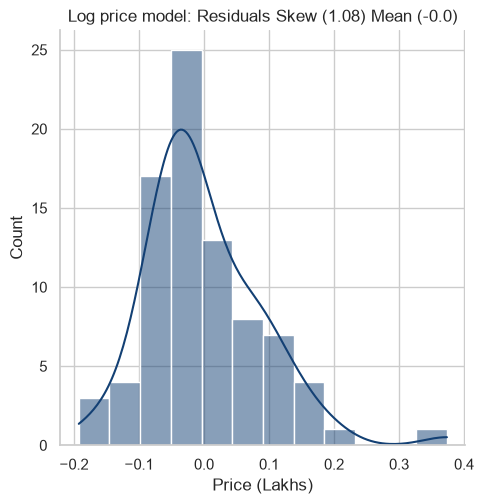

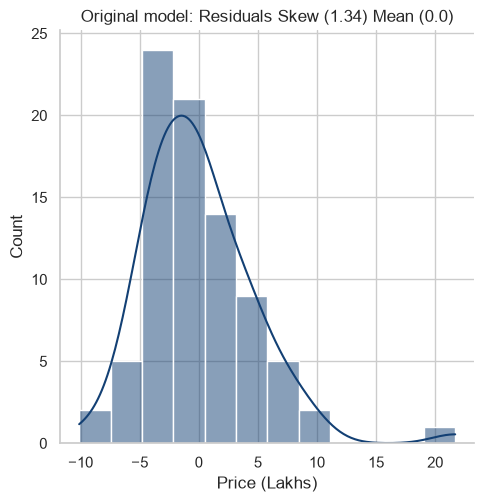

In [60]:
log_resid_mean_dwarka = round(log_residuals_dwarka.mean(), 2)
log_resid_skew_dwarka = round(log_residuals_dwarka.skew(), 2)

sns.displot(log_residuals_dwarka, kde=True, color='#134074')
plt.title(f'Log price model: Residuals Skew ({log_resid_skew_dwarka}) Mean ({log_resid_mean_dwarka})')
plt.show()

sns.displot(residuals_dwarka, kde=True, color='#134074')
plt.title(f'Original model: Residuals Skew ({resid_skew_dwarka}) Mean ({resid_mean_dwarka})')
plt.show()

The final residual distribution comparison confirms that the logarithmic data transformation successfully optimized the model’s residuals structure.
• The Mean: In both models, the mean sits at an absolute 0.0 (rounded to -0.0 in the log model). This visually validates that the regression model is operating correctly, keeping the mathematical predictions perfectly centered and balanced across the entire training dataset.
• The Skewness Improvement: A comparison of the distributions shows an improvement. The original model’s residuals had a right-hand skewness score of 1.34. By applying the log scale, the new model successfully dropped the skewness score to 1.08.
Looking at the charts shows why this drop in skewness score is so important for on the job house price prediction. While the log transformation could not remove the isolated under-predicted property outlier (which is still visible on both histograms), it successfully compressed the overall residual spread. The original model's residuals fluctuated widely between -10 and +10 Lakhs. The log transformation narrowed down this variance, thus compressing the main bell curve to sit between the range of -0.2 and +0.2 on the log scale. With an improvement in the shape of the bell curve, a much more reliable prediction model is the result.

To finalize the assessment of the predictive models for Dwarka Mor, their performance must be checked against the test data (the 20 % of the data that the model has not yet seen, as it used only 80% of the data during its training phase). This proves just how accurate the models are at making effective price predictions. The following code calculates the out-of-sample R-squared scores of the test data for both the original price model and the transformed logarithmic model. These R-squared scores inform how effectively each regression model deals with new property data and confirms whether or not the predictive accuracy remains stable beyond the initial data training.

In [61]:
print(f'Original Model Test Data r-squared: {regr_dwarka.score(X_test_dwarka, y_test_dwarka):.2}')
print(f'Log Model Test Data r-squared: {log_regr_dwarka.score(X_test_dwarka, log_y_test_dwarka):.2}')

Original Model Test Data r-squared: 0.71
Log Model Test Data r-squared: 0.68


The R-squared scores are slightly different, and it looks to the untrained eye that the model that used the original (non-logarithmic) prices performed better. In actual fact, the difference is only 0.03. This is a minuscule difference,  and because these two models operate on entirely different numeric scales (raw units vs. log units), a direct comparison of the R-squared values cannot be made.  Using a log scale compresses large numbers and in this case has reduced the residual variance, showing itself to be the better model to use.

In [62]:
features_dwarka = dwarka_mor[['Area', 'No. of Bedrooms', 'Resale', 'LiftAvailable', 'CarParking', 'Intercom', 'PowerBackup']]
average_vals_dwarka = features_dwarka.mean().values
property_stats_dwarka = pd.DataFrame(data=average_vals_dwarka.reshape(1, len(features_dwarka.columns)), 
                              columns=features_dwarka.columns)
property_stats_dwarka

,Area,No. of Bedrooms,Resale,LiftAvailable,CarParking,Intercom,PowerBackup
0,938.75,3.125,0.048077,0.548077,0.384615,0.519231,0.134615


In [63]:
log_estimate_dwarka = log_regr_dwarka.predict(property_stats_dwarka)[0]
print(f'The log price estimate is ${log_estimate_dwarka:.3}')

est_lakhs_dwarka = np.exp(log_estimate_dwarka) * 1000
print(f'The property is estimated to be worth ₹{est_lakhs_dwarka:.6}')

The log price estimate is $3.94
The property is estimated to be worth ₹51391.9


In [64]:
Area_dwarka = 1000
No_of_Bedrooms_dwarka = 5
Resale_dwarka = True 
Car_Parking_dwarka = True
Lift_Available_dwarka = True
Power_Backup_dwarka = True
Intercom_dwarka = True

In [65]:
property_stats_dwarka['Area'] = Area_dwarka
property_stats_dwarka['No. of Bedrooms'] = No_of_Bedrooms_dwarka

if Resale_dwarka:
    property_stats_dwarka['Resale'] = 1
else:
    property_stats_dwarka['Resale'] = 0

if Car_Parking_dwarka:
    property_stats_dwarka['CarParking'] = 1
else:
    property_stats_dwarka['CarParking'] = 0

if Lift_Available_dwarka:
    property_stats_dwarka['LiftAvailable'] = 1
else:
    property_stats_dwarka['LiftAvailable'] = 0
    
if Power_Backup_dwarka:
    property_stats_dwarka['PowerBackup'] = 1
else:
    property_stats_dwarka['PowerBackup'] = 0

if Intercom_dwarka:
    property_stats_dwarka['Intercom'] = 1
else:
    property_stats_dwarka['Intercom'] = 0



In [66]:
log_estimate_dwarka = log_regr_dwarka.predict(property_stats_dwarka)[0]
print(f'The log price estimate is {log_estimate_dwarka:.3}')

# Convert Log Prices to Acutal Dollar Values
est_lakhs_dwarka = np.e**log_estimate_dwarka * 1000
print(f'The property is estimated to be worth ₹{est_lakhs_dwarka:.6}')

The log price estimate is 4.16
The property is estimated to be worth ₹64294.6


### 6.2.2 Multivariate Regression of Uttam Nagar

Uttam Nagar is the smaller of the two locations, whose data will be used for the second regression model. It contains 74 properties. 
As previously stated, 5 independent feature variables can be used safely in the regression model, which satisfies the general rule that the sample-to-variable ratio is at least 15:1. The structural and amenity variables that will be used are:
- Area
- Number of Bedrooms
- Resale
- Lift Available
- Car Parking

The first task needed to ready the Uttam Nagar dataset for its regression model is to separate the variables into the target variable (Price (Lakhs)) and the 5 selected feature variables. As done earlier with Dwarka Mor, the data was then split 80/20 into training and testing sets. This gives 80% of the data over for the training of the regression model and 20% for its testing, this makes sure that the model can be assessed objectively on the 20% test data. A fixed random_state was applied to guarantee the reproducibility of the split.

In [67]:
target_uttam = uttam_nagar['Price (Lakhs)']
features_uttam = uttam_nagar[['Area', 'No. of Bedrooms', 'Resale', 'LiftAvailable', 'CarParking']]

X_train_uttam, X_test_uttam, y_train_uttam, y_test_uttam = train_test_split(features_uttam, 
                                                    target_uttam, 
                                                    test_size=0.2, 
                                                    random_state=10)

To see that the dataset was correctly split 80/20, a check was carried out to calculate the exact distribution of the rows. The printing out of these proportions confirms that the training and testing data sets cleanly follow the 80/20 split.

In [68]:
# % of training set
train_pct_uttam = 100*len(X_train_uttam)/len(features_uttam)
print(len(X_train_uttam))
print(len(features_uttam))
print(f'Training data is {train_pct_uttam:.3}% of the total data.')

# % of test data set
print(X_test_uttam.shape)
print(features_uttam.shape)

test_pct_uttam = 100*X_test_uttam.shape[0]/features_uttam.shape[0]
print(f'Test data makes up the remaining {test_pct_uttam:0.3}%.')

59
74
Training data is 79.7% of the total data.
(15, 5)
(74, 5)
Test data makes up the remaining 20.3%.


The training and testing datasets satisfy the requirements for a multiple regression model for Uttam Nagar and the model was created and fitted using the training data. After its training, the R-squared value was calculated for the training data to see how well the five variables explain the differences in property prices.

In [69]:
regr_uttam = LinearRegression()
regr_uttam.fit(X_train_uttam, y_train_uttam)
rsquared_uttam = regr_uttam.score(X_train_uttam, y_train_uttam)

print(f'Training data r-squared: {rsquared_uttam:.2}')

Training data r-squared: 0.45


This R-squared value of 0.45 demonstrates that 45% of house price variability in Uttam Nagar is down to the effects of these five feature variables. Naturally, the Dwarka Mor model benefitted from having an extra 2 feature variables. This obviously lends itself to a higher level of accuracy in its price predictions. 
This gap also reflects what was seen in our earlier bivariate analyses of price vs. area: Uttam Nagar showed a much lower R-squared score than Dwarka Mor did, thus using area as a feature variable for house prices in Uttam Nagar will give a less accurate pricing. Another possible reason could be the smaller data size (74 compared to 104 for Dwarka Mor).

After the successful fitting of the regression model to the Uttam Nagar training dataset, the mathematical weights connected to each of the feature variables need to be found. These will be presented below in a pandas DataFrame.

In [70]:
regr_coef_uttam = pd.DataFrame(data=regr_uttam.coef_, index=X_train_uttam.columns, columns=['Coefficient'])
regr_coef_uttam

,Coefficient
Area,0.039662
No. of Bedrooms,2.011620
Resale,4.445451
LiftAvailable,0.138656
CarParking,3.237429


The coefficients shown above explain the extent to which the 5 feature variables influence property prices in Uttam Nagar. 
As explained in the case of Dwarka Mor, they can be used to find the premiums of homes that have an extra bedroom etc.
For the continuous features, each additional square foot of Area adds 0.0397 Lakhs to a property's value, while an extra Bedroom gives an extra 2.01 Lakhs to the house price. For the binary utility variables, going from 0 to 1 adds to the baseline price: having car parking facilities adds 3.24 Lakhs, while a Lift adds a only 0.14 Lakhs to a property. Most notably, a resale property has the strongest influence on prices in the Uttam Nagar housing market: adding 4.45 Lakhs to the overall price value.

Below is an example, which illustrates the increase in house price that results from having an extra bedroom in Uttam Nagar.

In [71]:
premium_uttam = regr_coef_uttam.loc ['No. of Bedrooms'].values[0] 
print(f'The price premium for having an extra room is ₹{premium_uttam:.5} Lakhs')

The price premium for having an extra room is ₹2.0116 Lakhs


To evaluate how effective the regression model is, it is necessary to look at the predicted prices compared to the training data and check the resulting residuals. The regression model is used to calculate the predicted property values for Uttam Nagar and the subsequent residuals are calculated. These represent the differences between the actual housing prices and the model's predictions.

In [72]:
predicted_vals_uttam = regr_uttam.predict(X_train_uttam)
residuals_uttam = (y_train_uttam - predicted_vals_uttam)

A scattergraph can now be produced using the calculated predicted prices and residuals that shows the true prices (from the training data) vs. the predicted prices generated by the regression model, with a line of perfect identity (y = x) passing through all the data points. A second scattergraph can be created that shows the predicted prices against their corresponding residual errors, to check for any errors made by our regression model.

<>:4: SyntaxWarning: invalid escape sequence '\h'
<>:6: SyntaxWarning: invalid escape sequence '\h'
<>:12: SyntaxWarning: invalid escape sequence '\h'
<>:4: SyntaxWarning: invalid escape sequence '\h'
<>:6: SyntaxWarning: invalid escape sequence '\h'
<>:12: SyntaxWarning: invalid escape sequence '\h'
C:\Users\jhrdc\AppData\Local\Temp\ipykernel_10780\1159969392.py:4: SyntaxWarning: invalid escape sequence '\h'
  plt.title(f'Actual vs Predicted Prices: $y _i$ vs $\hat y_i$', fontsize=17)
C:\Users\jhrdc\AppData\Local\Temp\ipykernel_10780\1159969392.py:6: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel('Predicted prices 000s $\hat y _i$', fontsize=14)
C:\Users\jhrdc\AppData\Local\Temp\ipykernel_10780\1159969392.py:12: SyntaxWarning: invalid escape sequence '\h'
  plt.xlabel('Predicted Prices $\hat y _i$', fontsize=14)


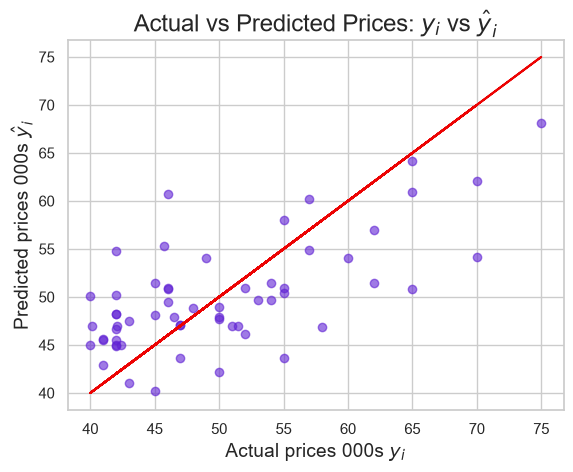

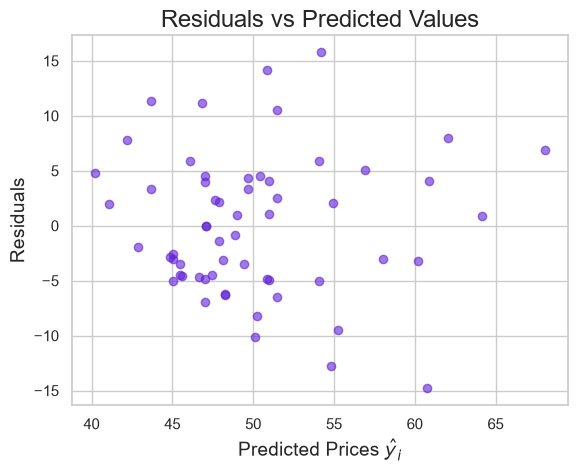

In [73]:
plt.figure(dpi=100)
plt.scatter(x=y_train_uttam, y=predicted_vals_uttam, c='#6022d4', alpha=0.6)
plt.plot(y_train_uttam, y_train_uttam, color='#EC0303')
plt.title(f'Actual vs Predicted Prices: $y _i$ vs $\hat y_i$', fontsize=17)
plt.xlabel('Actual prices 000s $y _i$', fontsize=14)
plt.ylabel('Predicted prices 000s $\hat y _i$', fontsize=14)
plt.show()

plt.figure(dpi=100)
plt.scatter(x=predicted_vals_uttam, y=residuals_uttam, c='#6022d4', alpha=0.6)
plt.title('Residuals vs Predicted Values', fontsize=17)
plt.xlabel('Predicted Prices $\hat y _i$', fontsize=14)
plt.ylabel('Residuals', fontsize=14)
plt.show()

Immediately, it can be seen that the datapoints are distributed further away from the line of perfect identity than in the equivalent scatter graph done for Dwarka Mor. It is obvious that the regression model here is not as strong as Dwarka Mor's.
The residuals further illustrate this point: they mostly sit within a wider range (-15 to +15, as compared to -10 to +10, in the case of Dwarka Mor).

To further investigate the residuals, the shape of their distribution needs to be measured. 
The mean and skewness scores of the residuals are calculated and then plotted on a histogram with a Kernel Density Estimate (KDE) line overlaying it. This allows the shape of the distribution to be visualised and, together with the skewness scores, the closeness of the curve to a normal distribution can be established.

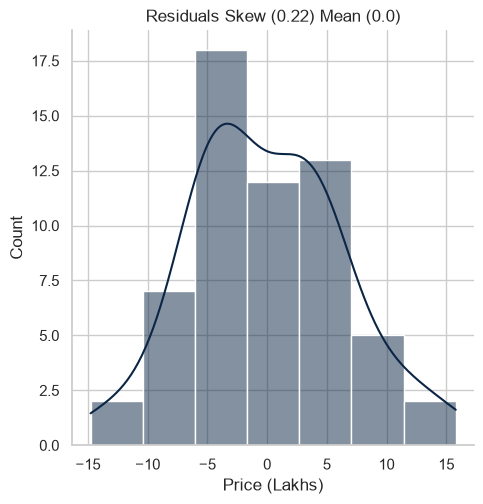

In [74]:
resid_mean_uttam = round(residuals_uttam.mean(), 2)
resid_skew_uttam = round(residuals_uttam.skew(), 2)

sns.displot(residuals_uttam, kde=True, color="#0B2545")
plt.title(f'Residuals Skew ({resid_skew_uttam}) Mean ({resid_mean_uttam})')
plt.show()

The curve has a general shape close to that of a normal distribution curve, but there is a mild skewness to the right. This is confirmed by the skewness score of 0.22.

Again, the target feature's (Price (Lakhs)) skewness will be calculated and a Seaborn displot will be used to generate a histogram of the prices, with a Kernel Density Estimate (KDE) line on top of the histogram.

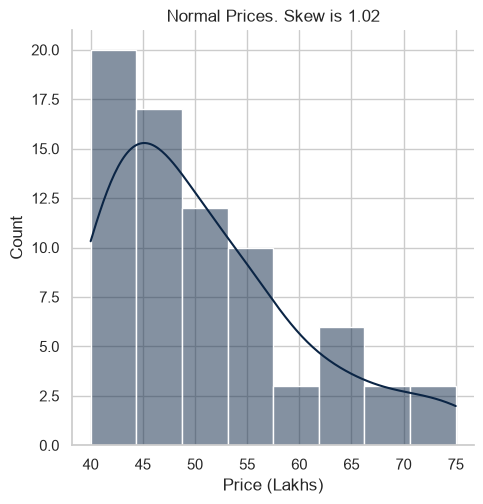

In [75]:
tgt_skew_uttam = uttam_nagar['Price (Lakhs)'].skew()
sns.displot(uttam_nagar['Price (Lakhs)'], kde='kde', color="#0B2545")
plt.title(f'Normal Prices. Skew is {tgt_skew_uttam:.3}')
plt.show()

As the above distribution is right-skewed,with a skewness score of 1.02, there is a chance that using a logarithmic data transformation could improve its skewness, bringing it closer to that of a normal distribution curve. The benefit of doing so will be the addition of further rigidity to the regression model.

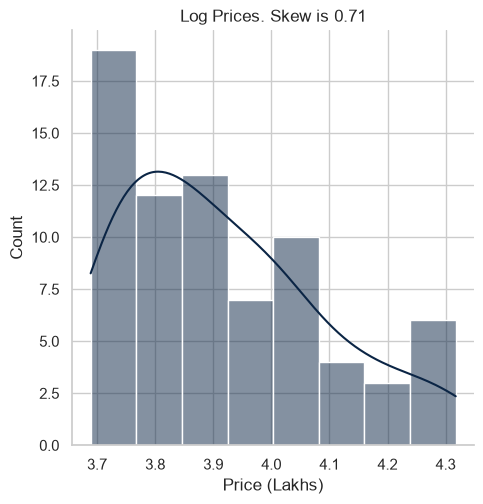

In [76]:
y_log_uttam = np.log(uttam_nagar['Price (Lakhs)'])
sns.displot(y_log_uttam, kde=True, color="#0B2545")
plt.title(f'Log Prices. Skew is {y_log_uttam.skew():.3}')
plt.show()

Converting the prices to a log scale is successful at lowering the skewness score from 1.02 to 0.71. This is an improvement, but the distribution still has a right-skewness. However, this lowering of skewness score is going to have an overall positive effect on the efficacy of our model.

As was done with the Dwarka Mor model, the natural log of the property prices was used in the building of the multiple regression model, substituting it for the original target variable (i.e. the non logged prices).

In [77]:
new_target_uttam = np.log(uttam_nagar['Price (Lakhs)']) # Use log prices
features_uttam = uttam_nagar[['Area', 'No. of Bedrooms', 'Resale', 'LiftAvailable', 'CarParking']]


X_train_uttam, X_test_uttam, log_y_train_uttam, log_y_test_uttam = train_test_split(features_uttam, 
                                                    new_target_uttam, 
                                                    test_size=0.2, 
                                                    random_state=10)

log_regr_uttam = LinearRegression()
log_regr_uttam.fit(X_train_uttam, log_y_train_uttam)
log_rsquared_uttam = log_regr_uttam.score(X_train_uttam, log_y_train_uttam)

log_predictions_uttam = log_regr_uttam.predict(X_train_uttam)
log_residuals_uttam = (log_y_train_uttam - log_predictions_uttam)

print(f'Training data r-squared: {log_rsquared_uttam:.2}')

Training data r-squared: 0.42


The new model that targets log(Price(Lakhs)) for properties in Uttam Nagar has a training data R-squared of 0.42. Similarly to the case in Dwarka Mor, there is a very slight lowering of the R-squared (from 0.45 to 0.42), but it is a good compromise to make as using the log scale will compress the effect of price variations and stabilize the variance of the residuals.

The performance of the predictive models, must now be assessed against the test data. This shows their accuracy for making effective price predictions. The out-of-sample R-squared scores of the test data for both the original price model and the transformed model. 
These R-squared scores show the effectiveness of how each regression model deals with new data and confirms if the predictive accuracy remains stable after the initial data training.

In [78]:
print(f'Original Model Test Data r-squared: {regr_uttam.score(X_test_uttam, y_test_uttam):.2}')
print(f'Log Model Test Data r-squared: {log_regr_uttam.score(X_test_uttam, log_y_test_uttam):.2}')

Original Model Test Data r-squared: 0.69
Log Model Test Data r-squared: 0.66


The reduction of the R-squared score in the log model is only very small: 0.03. This is a minor trade-off to make when deploying the log model. Because these two models operate on completely different numeric scales (raw units vs. log units), a direct comparison of their R-squared values cannot be made. Any minor visual differences in raw predictive qualities will be barely noticeable on the job, and because the log transformation successfully compressed the residual variance, it represents a fundamentally more stable model for price predictions.

The coefficients need to be re-calculated to see how the log-transformed property prices are affected by the feature variables.

In [79]:
df_coef_uttam = pd.DataFrame(data=log_regr_uttam.coef_, index=X_train_uttam.columns, columns=['coef'])
df_coef_uttam

,coef
Area,0.000727
No. of Bedrooms,0.042311
Resale,0.090046
LiftAvailable,-0.002202
CarParking,0.054925


As explained earlier in the case of Dwarka Mor, this new regression model uses a log scale, and so these new coefficients represent the percentage change in house prices rather than the flat Lakh amounts. Multiplying these decimals by 100 gives the exact percentage value each feature adds or subtracts from a home in Uttam Nagar. For example, each extra square foot of area adds 0.07% to the price, an extra bedroom adds 4.23%, car parking facilities add 5.49%, while a Lift reduces the value by 0.22%.

As was done for Dwarka Mor, the graphs of the new log regression model will be directly compared alongside the original price model for Uttam Nagar.
The first two scatter graphs map the Actual vs. Predicted values (logged and raw) against a line of perfect identity to assess predictive accuracy across both numeric scales. The final two graphs map the Residuals vs. Fitted Values. This allows for a direct inspection of the error distributions, visually confirming if the logarithmic transformation successfully stabilized the residual variance and produced a healthier, more balanced residual cloud.

<>:4: SyntaxWarning: invalid escape sequence '\h'
<>:6: SyntaxWarning: invalid escape sequence '\h'
<>:12: SyntaxWarning: invalid escape sequence '\h'
<>:14: SyntaxWarning: invalid escape sequence '\h'
<>:20: SyntaxWarning: invalid escape sequence '\h'
<>:27: SyntaxWarning: invalid escape sequence '\h'
<>:4: SyntaxWarning: invalid escape sequence '\h'
<>:6: SyntaxWarning: invalid escape sequence '\h'
<>:12: SyntaxWarning: invalid escape sequence '\h'
<>:14: SyntaxWarning: invalid escape sequence '\h'
<>:20: SyntaxWarning: invalid escape sequence '\h'
<>:27: SyntaxWarning: invalid escape sequence '\h'
C:\Users\jhrdc\AppData\Local\Temp\ipykernel_10780\862238196.py:4: SyntaxWarning: invalid escape sequence '\h'
  plt.title(f'Actual vs Predicted Log Prices: $y _i$ vs $\hat y_i$ (R-Squared {log_rsquared_uttam:.2})', fontsize=17)
C:\Users\jhrdc\AppData\Local\Temp\ipykernel_10780\862238196.py:6: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel('Predicted Log Prices $\hat y _i$', fonts

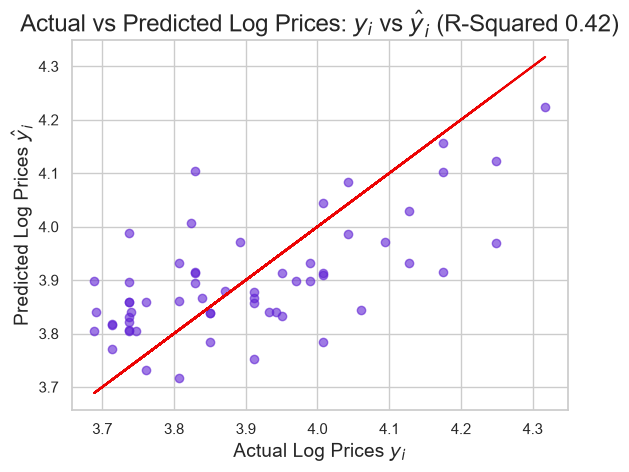

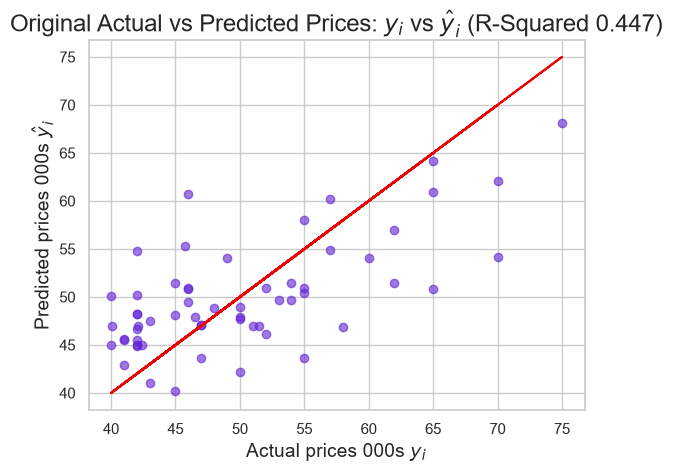

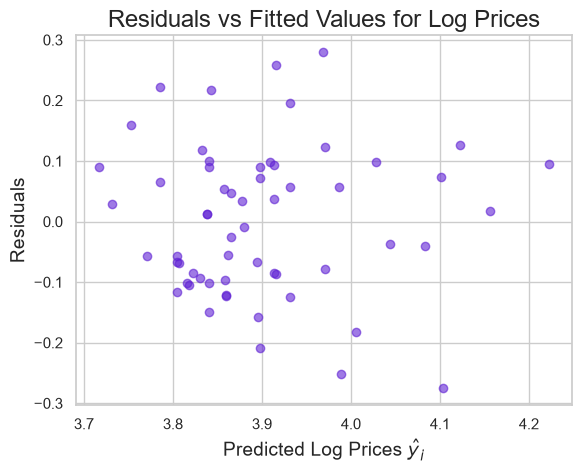

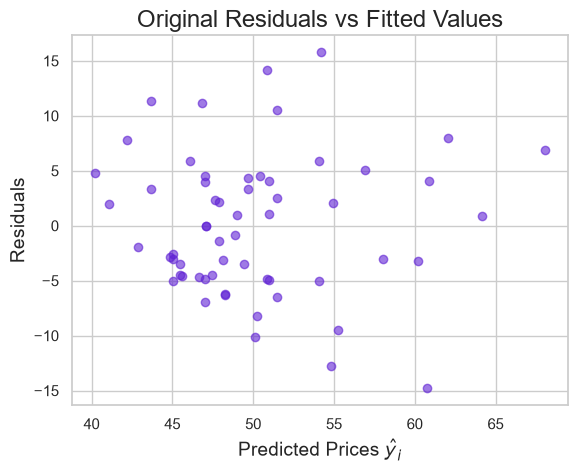

In [80]:
# Graph of Actual vs. Predicted Log Prices
plt.scatter(x=log_y_train_uttam, y=log_predictions_uttam, c="#6022d4", alpha=0.6)
plt.plot(log_y_train_uttam, log_y_train_uttam, color="#EC0303")
plt.title(f'Actual vs Predicted Log Prices: $y _i$ vs $\hat y_i$ (R-Squared {log_rsquared_uttam:.2})', fontsize=17)
plt.xlabel('Actual Log Prices $y _i$', fontsize=14)
plt.ylabel('Predicted Log Prices $\hat y _i$', fontsize=14)
plt.show()

# Original Regression of Actual vs. Predicted Prices
plt.scatter(x=y_train_uttam, y=predicted_vals_uttam, c="#6022d4", alpha=0.6)
plt.plot(y_train_uttam, y_train_uttam, color="#EC0303")
plt.title(f'Original Actual vs Predicted Prices: $y _i$ vs $\hat y_i$ (R-Squared {rsquared_uttam:.3})', fontsize=17)
plt.xlabel('Actual prices 000s $y _i$', fontsize=14)
plt.ylabel('Predicted prices 000s $\hat y _i$', fontsize=14)
plt.show()

# Residuals vs Predicted values (Log prices)
plt.scatter(x=log_predictions_uttam, y=log_residuals_uttam, c="#6022d4", alpha=0.6)
plt.title('Residuals vs Fitted Values for Log Prices', fontsize=17)
plt.xlabel('Predicted Log Prices $\hat y _i$', fontsize=14)
plt.ylabel('Residuals', fontsize=14)
plt.show()

# Residuals vs Predicted values
plt.scatter(x=predicted_vals_uttam, y=residuals_uttam, c="#6022d4", alpha=0.6)
plt.title('Original Residuals vs Fitted Values', fontsize=17)
plt.xlabel('Predicted Prices $\hat y _i$', fontsize=14)
plt.ylabel('Residuals', fontsize=14)
plt.show()



The first two graphs offer little difference visually to determine whether or not using the log(prices) was worth the effort. Thankfully, the numerical metrics provide the necessary evidence: using the log scale brings the training R-squared score down slightly from 0.447 to 0.42. This minor drop is an excellent compromise, as using the log target successfully compressed our original price skewness from 1.02 to 0.71, making the log scale highly valuable for building a more stable and effective model overall.
For the residual graphs, the similar clustering of the data points around the zero-error line implies there isn't much visual difference, but because the log scale compresses the overall spread of these errors, the resulting model is far more reliable against extreme pricing variance.

To further investigate the prediction residuals of both of our models, the shape of their distribution needs to be assessed.
The mean and skewness scores of the residuals are calculated and then plotted on a histogram with a Kernel Density Estimate (KDE) line overlaying it. This allows for the visualisation of the distribution shape, which together with the skewness scores, can show the closeness of the curve to a normal distribution.

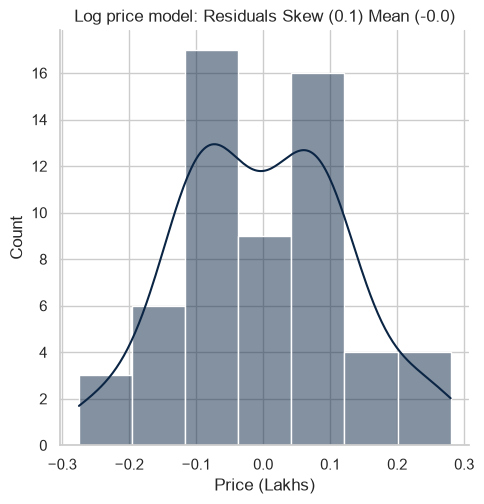

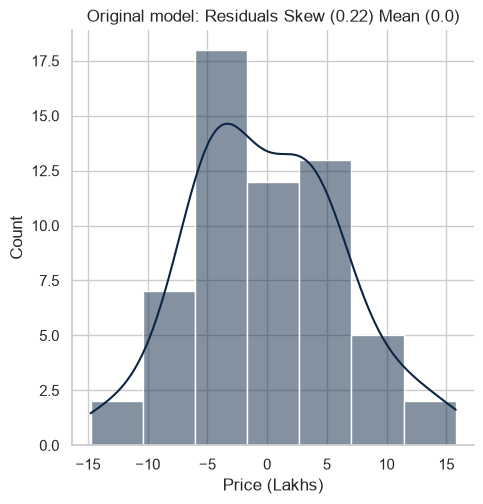

In [81]:
# Distribution of Residuals (log prices) - checking for normality
log_resid_mean_uttam = round(log_residuals_uttam.mean(), 2)
log_resid_skew_uttam = round(log_residuals_uttam.skew(), 2)

sns.displot(log_residuals_uttam, kde=True, color="#0B2545")
plt.title(f'Log price model: Residuals Skew ({log_resid_skew_uttam}) Mean ({log_resid_mean_uttam})')
plt.show()

sns.displot(residuals_uttam, kde=True, color="#0B2545")
plt.title(f'Original model: Residuals Skew ({resid_skew_uttam}) Mean ({resid_mean_uttam})')
plt.show()

The final residual distribution comparison confirms that the logarithmic data transformation successfully optimized the model’s residuals structure.
The Mean: In both models, the mean sits at 0.0. This visually validates that the regression model is operating correctly, keeping the predictions perfectly centered and balanced across the entire training dataset.
The Skewness Improvement: A comparison of the distributions shows an improvement. The original model’s residuals had a very slight skewness to the right and a score of 0.22. By applying the log scale, the new model successfully dropped the skewness score to 0.1.
This drop in the skewness score is valuable for on-the-job house price prediction. Even though the original model's residuals were already fairly well-balanced, the log transformation successfully compressed their overall spread. The original model's residuals fluctuated widely between -15 and +15 Lakhs. The log transformation narrowed down this variance, compressing the main bell curve to sit within a much more stable range of -0.3 and +0.3 on the log scale. With the smooth curve sitting completely symmetrical right over the center line, a much more reliable prediction model is the result.

The code below evaluates how well both the original and log-transformed regression models perform on the test data that was hidden from the model during the training phase of its development. Checking the R-squared scores is the ultimate way to prove that the regression models remain reliable and effective when confronted with a new set of properties.

In [82]:
print(f'Original Model Test Data r-squared: {regr_uttam.score(X_test_uttam, y_test_uttam):.2}')
print(f'Log Model Test Data r-squared: {log_regr_uttam.score(X_test_uttam, log_y_test_uttam):.2}')

Original Model Test Data r-squared: 0.69
Log Model Test Data r-squared: 0.66


The reduction of the R-squared score in the log model is only very small: 0.03. This is a minor trade-off to make when deploying the log model. Because these two models operate on completely different numeric scales (raw units vs. log units), a direct comparison of their R-squared values cannot be made. Any minor visual differences in raw predictive qualities will be barely noticeable on the job, and because the log transformation successfully compressed the residual variance, it represents a fundamentally more stable model for price predictions.

# 7. Predictive Deployment & Evaluation

## 7.1 Estimating Average House Prices

This section uses the regression model to predict house prices in both of the locations. Based on the specific tailoring of the feature variables, a predicted price can be calculated, depending on size, number of bedrooms and whether or not it possesses the amenities (obviously, only the features used in each particular regression model can be considered).

### 7.1.1 Dwarka Mor

To establish a realistic baseline for the predictions, the average of every single feature needs to be calculated. A new dataset is created in the next code cell (features_dwarka) and contains the seven categories used in the regression model. The code below calculates these feature means and organises them into a single-row pandas DataFrame. This allows for the establishment of a standardised baseline value, what the "average" home looks like, so that it can be passed into the regression models to predict property values.

In [83]:
features_dwarka = dwarka_mor[['Area', 'No. of Bedrooms', 'Resale', 'LiftAvailable', 'CarParking', 'Intercom', 'PowerBackup']]
average_vals_dwarka = features_dwarka.mean().values
property_stats_dwarka = pd.DataFrame(data=average_vals_dwarka.reshape(1, len(features_dwarka.columns)), 
                                     columns=features_dwarka.columns)
property_stats_dwarka

,Area,No. of Bedrooms,Resale,LiftAvailable,CarParking,Intercom,PowerBackup
0,938.75,3.125,0.048077,0.548077,0.384615,0.519231,0.134615


The outputted table outlines the exact characteristics of the average property in the Dwarka Mor dataset. A typical home in this sample has an area of approximately 938.75 square feet and averages 3.13 bedrooms. For the binary features, the decimals reveal the exact proportions across the dataset: approximately 54.8% of the properties have a lift available, 51.9% have an intercom system, 38.5% include car parking, and 13.5% are equipped with power backup. Notably, only about 4.8% of the listings are classified as resale properties, showing that new construction dominates this specific sample and, most likely, the whole of Dwarka Mor.

Using these average category values, a prediction can be made for the average property in Dwarka Mor (based on the seven feature variables used in the regression model). 
The predicted price will be a log estimate that must be transformed to a non logged value.

In [84]:
log_estimate_dwarka = log_regr_dwarka.predict(property_stats_dwarka)[0]
print(f'The log price estimate is {log_estimate_dwarka:.3}')

est_lakhs_dwarka = np.exp(log_estimate_dwarka)
print(f'The property is estimated to be worth ₹{est_lakhs_dwarka:.4} Lakhs')

The log price estimate is 3.94
The property is estimated to be worth ₹51.39 Lakhs


Using the regression model, the baseline house price in Dwarka Mor, in the 40-80 Lakhs bracket is ₹51.39 Lakhs.

### 7.1.2 Uttam Nagar

The same procedure will be followed for Uttam Nagar, noting that because of its smaller sample size, 5 feature variables are being used, as compared to seven in the case of Dwarka Mor.

In [85]:
features_uttam = uttam_nagar[['Area', 'No. of Bedrooms', 'Resale', 'LiftAvailable', 'CarParking']]
average_vals_uttam = features_uttam.mean().values
property_stats_uttam = pd.DataFrame(data=average_vals_uttam.reshape(1, len(features_uttam.columns)), 
                              columns=features_uttam.columns)
property_stats_uttam

,Area,No. of Bedrooms,Resale,LiftAvailable,CarParking
0,939.256757,3.094595,0.202703,0.608108,0.310811


The baseline property in Uttam Nagar has the characteristics as seen in the above table outlines. The "average" home in this sample has an area of approximately 939.26 square feet and has an average of 3.09 bedrooms. For the amenities, 60.8% of the properties have a lift available, 31.1% include car parking, and 20.3% are resale properties. The % of resale properties is over four times greater than in Dwarka Mor (which has only 4.8% of its homes listed as resale properties).

Now it is possible for a prediction to be made for the average property in Uttam Nagar (based on the five feature variables used in the regression model). 
The predicted price will be a log estimate that must be transformed to a non logged value.

In [86]:
log_estimate_uttam = log_regr_uttam.predict(property_stats_uttam)[0]
print(f'The log price estimate is {log_estimate_uttam:.3}')

est_lakhs_uttam = np.exp(log_estimate_uttam)
print(f'The property is estimated to be worth ₹{est_lakhs_uttam:.4} Lakhs')

The log price estimate is 3.91
The property is estimated to be worth ₹49.89 Lakhs


The baseline property in Uttam Nagar is ₹49.8876 Lakhs. This value accords with previously made assumptions that Dwarka Mor is the slightly more upmarket neighbourhood, where the baseline proeprty price was calculated at ₹51.39 Lakhs.

## 7.2 Estimating Prices with Specific Features (Advanced Premium)

### 7.2.1 Dwarka Mor

To test the model out, the seven features can be customised. Setting the custom values is done in the next cell.

In [87]:
# Define Property Characteristics
Area_dwarka = 600
No_of_Bedrooms_dwarka = 5
Resale_dwarka = False 
Car_Parking_dwarka = False
Lift_Available_dwarka = False
Power_Backup_dwarka = False
Intercom_dwarka = False

With the custom features set, they can be inserted into the DataFrame, as follows:

In [88]:
property_stats_dwarka['Area'] = Area_dwarka
property_stats_dwarka['No. of Bedrooms'] = No_of_Bedrooms_dwarka

if Resale_dwarka:
    property_stats_dwarka['Resale'] = 1
else:
    property_stats_dwarka['Resale'] = 0

if Car_Parking_dwarka:
    property_stats_dwarka['CarParking'] = 1
else:
    property_stats_dwarka['CarParking'] = 0

if Lift_Available_dwarka:
    property_stats_dwarka['LiftAvailable'] = 1
else:
    property_stats_dwarka['LiftAvailable'] = 0
    
if Power_Backup_dwarka:
    property_stats_dwarka['PowerBackup'] = 1
else:
    property_stats_dwarka['PowerBackup'] = 0

if Intercom_dwarka:
    property_stats_dwarka['Intercom'] = 1
else:
    property_stats_dwarka['Intercom'] = 0



With all parameters set, the prediction can be made.

In [89]:
# Make prediction
log_estimate_dwarka = log_regr_dwarka.predict(property_stats_dwarka)[0]
print(f'The log price estimate is {log_estimate_dwarka:.3}')

# Convert Log Prices to Acutal Dollar Values
est_lakhs_dwarka = np.e**log_estimate_dwarka
print(f'The property is estimated to be worth ₹{est_lakhs_dwarka:.4} Lakhs')

The log price estimate is 3.66
The property is estimated to be worth ₹38.95 Lakhs


For a home in Dwaraka Mor, with features as described in cell 269, the predicted valaution of the property is ₹38.95 Lakhs.

### 7.2.2 Uttam Nagar

To test the model out, the five features can be customised. Once more, the customised values are done:

In [90]:
Area_uttam = 900
No_of_Bedrooms_uttam = 4
Resale_uttam = True 
Car_Parking_uttam = False
Lift_Available_uttam = True

With the custom features set, they can be inserted into the DataFrame:

In [91]:
property_stats_uttam['Area'] = Area_dwarka
property_stats_uttam['No. of Bedrooms'] = No_of_Bedrooms_uttam

if Resale_uttam:
    property_stats_uttam['Resale'] = 1
else:
    property_stats_uttam['Resale'] = 0

if Car_Parking_uttam:
    property_stats_uttam['CarParking'] = 1
else:
    property_stats_uttam['CarParking'] = 0

if Lift_Available_uttam:
    property_stats_uttam['LiftAvailable'] = 1
else:
    property_stats_uttam['LiftAvailable'] = 0

In [92]:
# Make prediction
log_estimate_uttam = log_regr_uttam.predict(property_stats_uttam)[0]
print(f'The log price estimate is {log_estimate_uttam:.3}')

# Convert Log Prices to Acutal Dollar Values
est_lakhs_uttam = np.e**log_estimate_uttam
print(f'The property is estimated to be worth ₹{est_lakhs_uttam:.4} Lakhs')

The log price estimate is 3.76
The property is estimated to be worth ₹42.75 Lakhs


The predicted price of a property in Uttam Nagar with features set (as in cell 278) is ₹42.75 Lakhs.

## 7.3 The Final Test: Comparing both locations with identical features of a customer's requirements

In the housing market, customers have their specific requirements for what they need in a property and, obviously, to get it for the best price possible is the ideal situation. Now, using the regression models, a direct comparison will be made property price of homes with the following specificiations. As the regression model for Dwarka Mor has two more feature variables assigned to it, the means of these two variables (as calculated earlier) will be used.

### 7.3.1 Example #1

Both homes will have the following features characteristics:

- Area: 800
- Number of Bedrooms: 3
- Resale: True
- Car Parking: False
- Lift Available: True

Setting these values for both locations. As Uttam Nagar's regression model doesn't use the variables of power backup and intercom, these are simply turned off (set to False) when we run the regression:

In [93]:
Area_dwarka = 800
No_of_Bedrooms_dwarka = 3
Resale_dwarka = True
Car_Parking_dwarka = False
Lift_Available_dwarka = True
Power_Backup_dwarka = False
Intercom_dwarka = False

Area_uttam = 800
No_of_Bedrooms_uttam = 3
Resale_uttam = True 
Car_Parking_uttam = False
Lift_Available_uttam = False


Insertion of the customised features into the DataFrames for each location:

In [94]:
property_stats_dwarka['Area'] = Area_dwarka
property_stats_dwarka['No. of Bedrooms'] = No_of_Bedrooms_dwarka

if Resale_dwarka:
    property_stats_dwarka['Resale'] = 1
else:
    property_stats_dwarka['Resale'] = 0

if Car_Parking_dwarka:
    property_stats_dwarka['CarParking'] = 1
else:
    property_stats_dwarka['CarParking'] = 0

if Lift_Available_dwarka:
    property_stats_dwarka['LiftAvailable'] = 1
else:
    property_stats_dwarka['LiftAvailable'] = 0
    
if Power_Backup_dwarka:
    property_stats_dwarka['PowerBackup'] = 1
else:
    property_stats_dwarka['PowerBackup'] = 0

if Intercom_dwarka:
    property_stats_dwarka['Intercom'] = 1
else:
    property_stats_dwarka['Intercom'] = 0

In [95]:
property_stats_uttam['Area'] = Area_uttam
property_stats_uttam['No. of Bedrooms'] = No_of_Bedrooms_uttam

if Resale_uttam:
    property_stats_uttam['Resale'] = 1
else:
    property_stats_uttam['Resale'] = 0

if Car_Parking_uttam:
    property_stats_uttam['CarParking'] = 1
else:
    property_stats_uttam['CarParking'] = 0

if Lift_Available_uttam:
    property_stats_uttam['LiftAvailable'] = 1
else:
    property_stats_uttam['LiftAvailable'] = 0

Now the final comparative predictions can be made.

In [96]:
# Make prediction
log_estimate_dwarka = log_regr_dwarka.predict(property_stats_dwarka)[0]
print(f'The log price estimate is {log_estimate_dwarka:.3}')

# Convert Log Prices to Acutal Dollar Values
est_lakhs_dwarka = np.e**log_estimate_dwarka
print(f'The property in Dwarka Mor is estimated to be worth ₹{est_lakhs_dwarka:.4} Lakhs')

The log price estimate is 3.77
The property in Dwarka Mor is estimated to be worth ₹43.53 Lakhs


In [97]:
# Make prediction
log_estimate_uttam = log_regr_uttam.predict(property_stats_uttam)[0]
print(f'The log price estimate is {log_estimate_uttam:.3}')

# Convert Log Prices to Acutal Dollar Values
est_lakhs_uttam = np.e**log_estimate_uttam
print(f'The property in Uttam Nagar is estimated to be worth ₹{est_lakhs_uttam:.4} Lakhs')

The log price estimate is 3.86
The property in Uttam Nagar is estimated to be worth ₹47.49 Lakhs


This is a remarkable finding- the most expensive of these property prices was found to be in Uttam Nagar. The regression has the ability to give the price based on the differing premiums of each category. This is great news for a buyer who, looking at the previously made assumption that Uttam Nagar was the cheaper neighbourhood. The regression model has in fact proven that the real bargain is to be found in Dwarka Mor.

### 7.3.2 Example #2

Setting of the values:

In [98]:
Area_dwarka = 1000
No_of_Bedrooms_dwarka = 5
Resale_dwarka = False
Car_Parking_dwarka = False
Lift_Available_dwarka = False
Power_Backup_dwarka = False
Intercom_dwarka = False

Area_uttam = 1000
No_of_Bedrooms_uttam = 5
Resale_uttam = False 
Car_Parking_uttam = False
Lift_Available_uttam = False

Insertion of the customised features into the DataFrames for each location:

In [99]:
property_stats_dwarka['Area'] = Area_dwarka
property_stats_dwarka['No. of Bedrooms'] = No_of_Bedrooms_dwarka

if Resale_dwarka:
    property_stats_dwarka['Resale'] = 1
else:
    property_stats_dwarka['Resale'] = 0

if Car_Parking_dwarka:
    property_stats_dwarka['CarParking'] = 1
else:
    property_stats_dwarka['CarParking'] = 0

if Lift_Available_dwarka:
    property_stats_dwarka['LiftAvailable'] = 1
else:
    property_stats_dwarka['LiftAvailable'] = 0
    
if Power_Backup_dwarka:
    property_stats_dwarka['PowerBackup'] = 1
else:
    property_stats_dwarka['PowerBackup'] = 0

if Intercom_dwarka:
    property_stats_dwarka['Intercom'] = 1
else:
    property_stats_dwarka['Intercom'] = 0

In [100]:
property_stats_uttam['Area'] = Area_uttam
property_stats_uttam['No. of Bedrooms'] = No_of_Bedrooms_uttam

if Resale_uttam:
    property_stats_uttam['Resale'] = 1
else:
    property_stats_uttam['Resale'] = 0

if Car_Parking_uttam:
    property_stats_uttam['CarParking'] = 1
else:
    property_stats_uttam['CarParking'] = 0

if Lift_Available_uttam:
    property_stats_uttam['LiftAvailable'] = 1
else:
    property_stats_uttam['LiftAvailable'] = 0

Comparison of the two predictions:

In [101]:
# Make prediction
log_estimate_dwarka = log_regr_dwarka.predict(property_stats_dwarka)[0]
print(f'The log price estimate is {log_estimate_dwarka:.3}')

# Convert Log Prices to Acutal Dollar Values
est_lakhs_dwarka = np.e**log_estimate_dwarka
print(f'The property in Dwarka Mor is estimated to be worth ₹{est_lakhs_dwarka:.4} Lakhs')

The log price estimate is 4.08
The property in Dwarka Mor is estimated to be worth ₹59.17 Lakhs


In [102]:
# Make prediction
log_estimate_uttam = log_regr_uttam.predict(property_stats_uttam)[0]
print(f'The log price estimate is {log_estimate_uttam:.3}')

# Convert Log Prices to Acutal Dollar Values
dollar_est = np.e**log_estimate_uttam
print(f'The property in Uttam Nagar is estimated to be worth ₹{dollar_est:.4} Lakhs')

The log price estimate is 4.0
The property in Uttam Nagar is estimated to be worth ₹54.63 Lakhs


This example is brilliant, as it proves the value of a multiple regression. It has the exact opposite result of the first one. It predicts that Uttam Nagar is the location where this particular property can be found for a lower price, which is what would have been expected had from the previous comparisons of features. The beauty of the multiple regressions is that not only can the cheaper neighbourhood be identified, but the price of such a home can be calculated, to a high degree of confidence.

# 8. Conclusions

This study has shown that no matter what feature variable is considered between locations, simply looking at comparison charts (in this case boxplots) cannot tell the full story about a home's price tag and the buyers are possibly limited by perceptions about what their budget limits them to, especially in terms of location. Studying the comparison charts has proven to be misleading as the prices of properties with and without certain amenities does not show a clear difference and in some cases, the presence of some amenities showed differing effects on house prices in the two areas of Dwarka Mor and Uttam Nagar. 

If a home buyer has to make the decision on what location offered the best opportunities for them, just having these charts would lead to confusion and frustrations. This is when the multiple regressions come into their own. They can calculate the prices of homes in two locations with the exact specifications that a home buyer is searching for. These multiple regression models save a lot of inconvenience and tell the customer the best location to search for their perfect property. The models do one thing no amount of comparing boxplots could ever do: find price tags of homes where the combination of feature variables could lend themselves to giving a lower price for a property in a slightly more upmarket region and, vice versa, a higher home value in a lower value area.

# 9. Appendices

### Appendix I

The link to the page where the data was sourced: https://www.kaggle.com/datasets/yasserbaderahmed/house-prices-in-delhi

### Appendix II

The linechart in cell 103 had its area rounded, so as the spikiness of the original line graph (below) could be smoothed out.

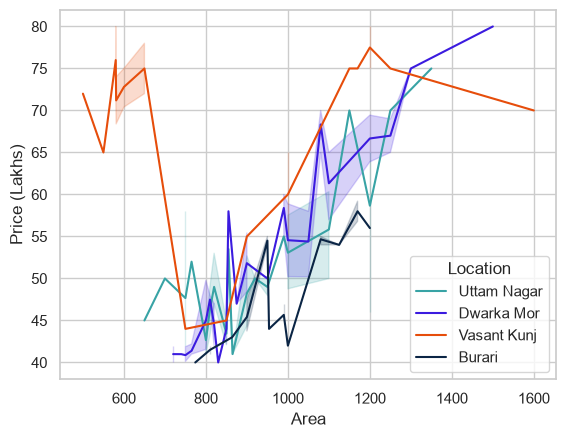

In [103]:
sns.lineplot(
    data=top4_loc,
    x='Area',       
    y='Price (Lakhs)',      
    hue='Location', 
    palette=colour_palette_dict)
plt.show()